<h3>**GRUPO #2**</h3>
<table>
      <head>
          <th>Integrante</th>
          <th>Carnet</th>
      </head>
      <body>
          <tr>
              <td>Alfredo Argueta Interiano</td>
              <td>AI252944</td>
          </tr>
          <tr>
              <td>Giovanni Alexander Escobar</td>
              <td>EM252920</td>
          </tr>
          <tr>
              <td>Ivo Luis Orellana Girón</td>
              <td>OG252913</td>
          </tr>
          <tr>
              <td>José Rodrigo López Torres</td>
              <td>LT170438</td>
          </tr>
          <tr>
              <td>Marlon Alexander Palacios Díaz</td>
              <td>PD252876</td>
          </tr>
      </body>
</table>

# Proyecto de Deep Learning: Predicción de Churn en Comercios

Con el objetivo de predecir el churn (abandono) de comercios, definiremos nuestro proyecto de la siguiente manera:
Se diseñará un modelo de deep learning para predecir si un comercio activo en un mes determinado (t) se volverá inactivo en el siguiente mes (t+1). Este analisis será basado en las transacciones completas de un año, lo que nos permitirá capturar patrones estacionales y tendencias a lo largo del tiempo.

Consideraciones hechas:
- El churn se definirá como un comercio que estuvo Activo en el mes T si sus transacciones en ese mes son igual o superiores a $15 USD, y se considera en riesgo de abandono si presenta una caída significativa en ventas de mas del 85% en el siguiente periodo.
- Se utilizará un enfoque de validación temporal, dividiendo los datos en conjuntos de entrenamiento, validación y prueba de manera secuencial para evitar el leakage de información. Hold-out temporal (train meses tempranos, validacion meses  siguientes, test último posible) Dentro del CV usaremos  TimeSeriesSplit dentro de train para tuning (no KFold random) para evitar leakage.



## Estrategia de Análisis y Modelado
1. **Análisis Exploratorio de Datos (EDA)**: Se realizará un análisis exhaustivo de los datos para entender su estructura, identificar patrones, detectar valores atípicos y comprender la distribución de las variables. Esto incluirá visualizaciones y estadísticas descriptivas.
2. Los datos transaccionales se transformarán en características agregadas por comercio y mes, como el número total de transacciones, el monto total transaccionado, la frecuencia de transacciones, entre otros. Estas características ayudarán a capturar el comportamiento de los comercios a lo largo del tiempo Y nos ayudarán a entrenar el churn.
3. Con los datos agrupados a nivel mensual y a nivel de Panel , se hará un análisis exploratorio rápido para entender la distribución mensual de las caracteristicas y entender el ciclo de vida de los comercios

# Importación de librerías y carga de datos

In [1]:
!pip install gdown

In [2]:
import os
import gdown
import pandas as pd
import numpy as np
import random
import json
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
#Ignorar warning
import warnings
warnings.filterwarnings('ignore')

#Establecer semillas
RANDOM_SEED = 42
# Establecemos la semilla para todas las librerías",

np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# Configura pandas para mostrar 2 decimales y formato normal
pd.options.display.float_format = '{:.2f}'.format

print("Librerias cargadas correctamente")

Librerias cargadas correctamente


In [3]:
#Descargar archivo CSV de Fintech almacenada en Google Drive a Google Colab
file_id = "1Ce6yctTxvYkv7lq8tDEr47iqSwtekNmj"
url = f"https://drive.google.com/uc?id={file_id}"
output = "fintech_data_2025.csv"

gdown.download(url, output, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1Ce6yctTxvYkv7lq8tDEr47iqSwtekNmj
From (redirected): https://drive.google.com/uc?id=1Ce6yctTxvYkv7lq8tDEr47iqSwtekNmj&confirm=t&uuid=41e0c26a-866d-4fc4-ac58-e73d9f36adb9
To: C:\Users\marlo\Documents\DLI629\Proyecto\fintech_data_2025.csv
100%|██████████| 153M/153M [00:21<00:00, 7.12MB/s] 


'fintech_data_2025.csv'

In [4]:
#Leer el archivo descargado en un dataframe para su uso

df=pd.read_csv(output)

In [5]:
df.columns

Index(['company_id', 'company_created_at', 'trx_created_at', 'amount',
       'transaction_type', 'transaction_status', 'rejection_reason',
       'category_name', 'state_name', 'city_name', 'kyc_level', 'tag',
       'is_taxpayer'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 822785 entries, 0 to 822784
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   company_id          822785 non-null  int64  
 1   company_created_at  822785 non-null  str    
 2   trx_created_at      822785 non-null  str    
 3   amount              822785 non-null  float64
 4   transaction_type    822785 non-null  str    
 5   transaction_status  822785 non-null  str    
 6   rejection_reason    40454 non-null   str    
 7   category_name       822785 non-null  str    
 8   state_name          340063 non-null  str    
 9   city_name           340063 non-null  str    
 10  kyc_level           822785 non-null  str    
 11  tag                 227403 non-null  float64
 12  is_taxpayer         822785 non-null  bool   
dtypes: bool(1), float64(2), int64(1), str(9)
memory usage: 76.1 MB


### 📘 Diccionario de Datos: Dataset de Transacciones

| Columna | Tipo de Dato | Descripción | Integridad / Nulos | Ejemplo/Formato |
| :--- | :--- | :--- | :--- | :--- |
| **company_id** | `int64` | Identificador único de la empresa. | 100% (822,785) | `10245` |
| **company_created_at** | `datetime`* | Fecha de registro de la empresa. | 100% | `2023-01-15 10:30:00` |
| **trx_created_at** | `datetime`* | Marca de tiempo de la transacción. | 100% | `2023-05-20 14:15:22` |
| **amount** | `float64` | Valor monetario de la operación. | 100% | `1550.50` |
| **transaction_type** | `string` | Tipo de movimiento (pago, cobro, etc). | 100% | `'POS'` |
| **transaction_status** | `string` | Estado (approved, pending, rejected). | 100% | `'SUCCEEDED'` |
| **rejection_reason** | `string` | Motivo de rechazo (si aplica). | **4.9%** (40,454) | `'FONDOS INSUFICIENTES'` |
| **category_name** | `string` | Sector comercial de la empresa. | 100% | `'Ropa, calzado y accesorios'` |
| **state_name** | `string` | Estado/Provincia de la operación. | **41.3%** (340,063)| `'San Salvador'` |
| **city_name** | `string` | Ciudad de la operación. | **41.3%** (340,063)| `'San Salvador'` |
| **kyc_level** | `json` | Nivel de verificación del usuario. | 100% | `'{"level_1":true,"level_2":true,"level_3":false}'` |
| **tag** | `float64` | Etiqueta numérica de seguimiento. | **27.6%** (227,403)| `1.0` |
| **is_taxpayer** | `bool` | Indicador si es contribuyente fiscal. | 100% | `True` |

> **Nota:** Las columnas marcadas con `*` aparecen originalmente como `object`. Se recomienda transformarlas con `pd.to_datetime()` para análisis temporal.

In [7]:
df.describe()

,company_id,amount,tag
count,822785.00,822785.00,227403.00
mean,24292.16,52.04,60.13
std,12731.46,8597.00,41.64
min,1.00,-50.00,29.00
25%,12485.00,6.00,34.00
50%,25079.00,13.20,38.00
75%,35399.00,30.00,78.00
max,49652.00,7757757.75,143.00


In [8]:
df.sample(10)

,company_id,company_created_at,trx_created_at,amount,transaction_type,transaction_status,rejection_reason,category_name,state_name,city_name,kyc_level,tag,is_taxpayer
266848,8067,2022-11-24 12:04:55.633779,2025-05-15 10:44:27.064000,55.00,LINK,SUCCEEDED,NaN,Educación y deportes,NaN,NaN,"{""level_1"":true,""level_2"":true,""level_3"":false}",NaN,True
727774,13454,2023-08-31 10:06:38.686818,2025-11-28 17:01:43.481000,59.50,POS,SUCCEEDED,NaN,Otro,NaN,NaN,"{""level_1"":true,""level_2"":true,""level_3"":false}",NaN,False
53089,10075,2023-03-14 12:50:15.480040,2025-01-29 18:24:05.833000,4.00,POS,SUCCEEDED,NaN,Belleza y cuidado personal,NaN,NaN,"{""level_1"":true,""level_2"":true,""level_3"":false}",NaN,False
311815,26702,2024-07-31 16:13:34.371299,2025-06-05 20:05:24.082000,23.00,POS,SUCCEEDED,NaN,Educación y deportes,NaN,NaN,"{""level_1"":true,""level_2"":true,""level_3"":false}",NaN,False
355663,35753,2025-02-06 17:54:33.734508,2025-06-26 20:21:36.899000,33.66,POS,SUCCEEDED,NaN,"Restaurantes, bares y hostelería",Santa Ana,Metapán,"{""level_1"":true,""level_2"":true,""level_3"":false}",NaN,False
480844,25585,2024-07-16 11:07:02.246233,2025-08-21 11:03:01.674000,166.50,POS-MSI,SUCCEEDED,NaN,Servicios Profesionales,NaN,NaN,"{""level_1"":true,""level_2"":true,""level_3"":false}",NaN,False
563089,26306,2024-07-25 12:32:39.688860,2025-09-25 16:45:20.393000,3.95,POS,REJECTED,51 - FONDOS INSUFICIENTES,"Restaurantes, bares y hostelería",NaN,NaN,"{""level_1"":true,""level_2"":true,""level_3"":false}",34.00,True
379870,25686,2024-07-17 09:01:28.221225,2025-07-07 13:46:48.481000,16.50,LINK,SUCCEEDED,NaN,"Restaurantes, bares y hostelería",NaN,NaN,"{""level_1"":true,""level_2"":true,""level_3"":false}",NaN,True
119542,35724,2025-02-06 09:43:50.611338,2025-03-03 12:12:00.705000,3.09,POS,SUCCEEDED,NaN,"Restaurantes, bares y hostelería",San Salvador,San Salvador,"{""level_1"":true,""level_2"":true,""level_3"":false}",29.00,False
456632,10459,2023-04-07 10:04:20.621062,2025-08-10 14:23:24.382000,40.50,POS,SUCCEEDED,NaN,"Restaurantes, bares y hostelería",NaN,NaN,"{""level_1"":true,""level_2"":true,""level_3"":false}",NaN,False


Ya que la importacion por default trajo Ids como Float, se convertirán a string para evitar confusiones y errores en el futuro. Asi mismo se moverán a datetime las fechas para facilitar su manejo.

In [9]:
df['company_id']=df['company_id'].astype(str)
df['company_created_at']=df['company_created_at'].astype('datetime64[ns]')
df['trx_created_at']=df['trx_created_at'].astype('datetime64[ns]')


<Figure size 1000x500 with 0 Axes>

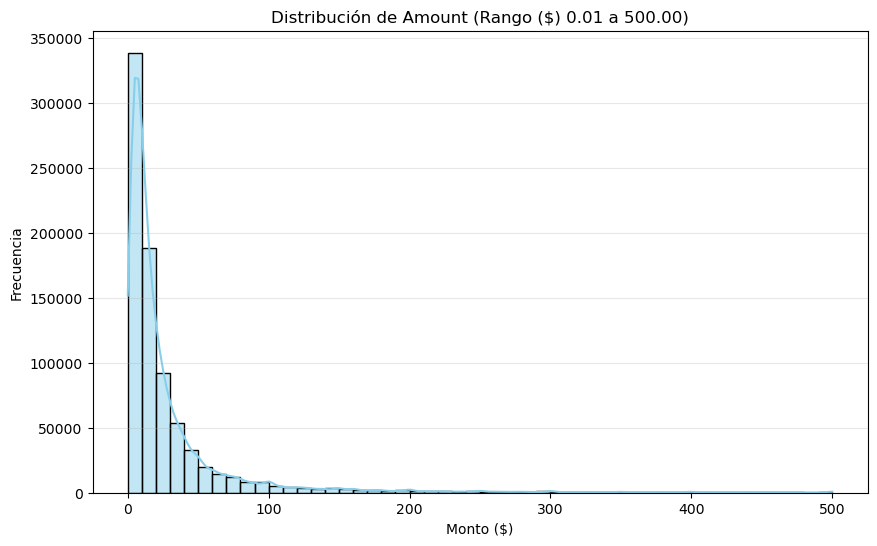

In [10]:
# ==========================================
# 3.1 ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# ==========================================

# --- ANÁLISIS UNIVARIADO ---

# A. Distribución de la variable 'amount' (Histograma y Densidad)
plt.figure(figsize=(10, 5))
# 1. Calcular los límites de los percentiles (ejemplo: 1% y 99%)
low, high = df['amount'].quantile([0.01, 0.99])

# 2. Filtrar los datos dentro de ese rango
filtered_amount = df[df['amount'].between(low, high)]['amount']

# 3. Graficar
plt.figure(figsize=(10, 6))
sns.histplot(filtered_amount, kde=True, color='skyblue', bins=50)

plt.title(f'Distribución de Amount (Rango ($) {low:.2f} a {high:.2f})')
plt.xlabel('Monto ($)')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [11]:
# 1. Filtrar solo los montos menores o iguales a cero
df_negativos = df[df['amount'] <= 0]

# 2. Agrupar por tipo de transacción y calcular métricas
resumen_negativos = df_negativos.groupby('transaction_status')['amount'].agg(['count', 'sum', 'mean']).reset_index()

# 3. Renombrar columnas para claridad
resumen_negativos.columns = ['Estado de Transacción', 'Cantidad de Registros', 'Suma Total Negativa', 'Promedio Negativo']

print(resumen_negativos)

  Estado de Transacción  Cantidad de Registros  Suma Total Negativa  \
0                 DRAFT                      7                 0.00   
1              REFUNDED                      2              -100.00   

   Promedio Negativo  
0               0.00  
1             -50.00  


In [12]:
# Filtrar solo los montos mayores a $500 (> Percentil 99)
total_registros = len(df)
mayores_500 = len(df[df['amount'] > 500])
porcentaje = (mayores_500 / total_registros) * 100

print(f"Registros totales: {total_registros:,}")
print(f"Registros > 500: {mayores_500:,}")
print(f"Porcentaje: {porcentaje:.2f}%")

# Esto te da el % de transacciones > 500 para cada categoría
reporte_categorias = df.assign(es_mayor_500 = df['amount'] > 500) \
                       .groupby('category_name')['es_mayor_500'] \
                       .mean() * 100

print(reporte_categorias.sort_values(ascending=False))

Registros totales: 822,785
Registros > 500: 8,125
Porcentaje: 0.99%
category_name
Servicio de transporte y mensajería   4.37
Servicios Profesionales               4.25
Turismo y recreación                  3.82
Autopartes, talleres y carwash        3.61
Otro                                  2.99
Electrónicos y computación            2.85
Médicos y profesionales de salud      2.53
Artes y galerías                      1.03
Educación y deportes                  0.87
Ropa, calzado y accesorios            0.68
Belleza y cuidado personal            0.39
Tiendas de conveniencia               0.19
Restaurantes, bares y hostelería      0.11
Name: es_mayor_500, dtype: float64


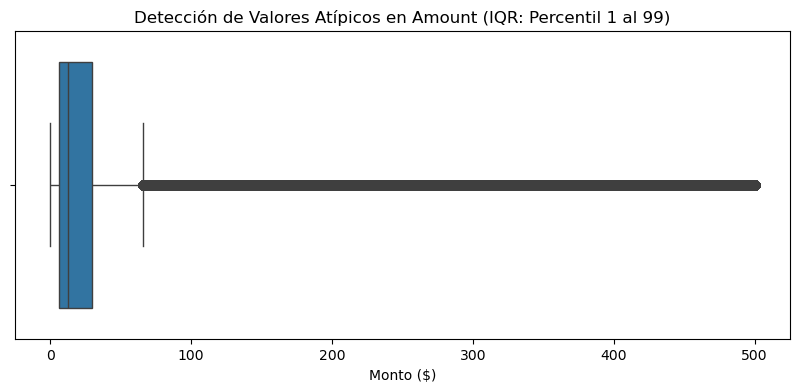

Estadísticas de Valores Faltantes:
                    Total Nulos  Porcentaje (%)
rejection_reason         782331           95.08
tag                      595382           72.36
city_name                482722           58.67
state_name               482722           58.67
company_id                    0            0.00
transaction_type              0            0.00
amount                        0            0.00
trx_created_at                0            0.00
company_created_at            0            0.00
category_name                 0            0.00
transaction_status            0            0.00
kyc_level                     0            0.00
is_taxpayer                   0            0.00


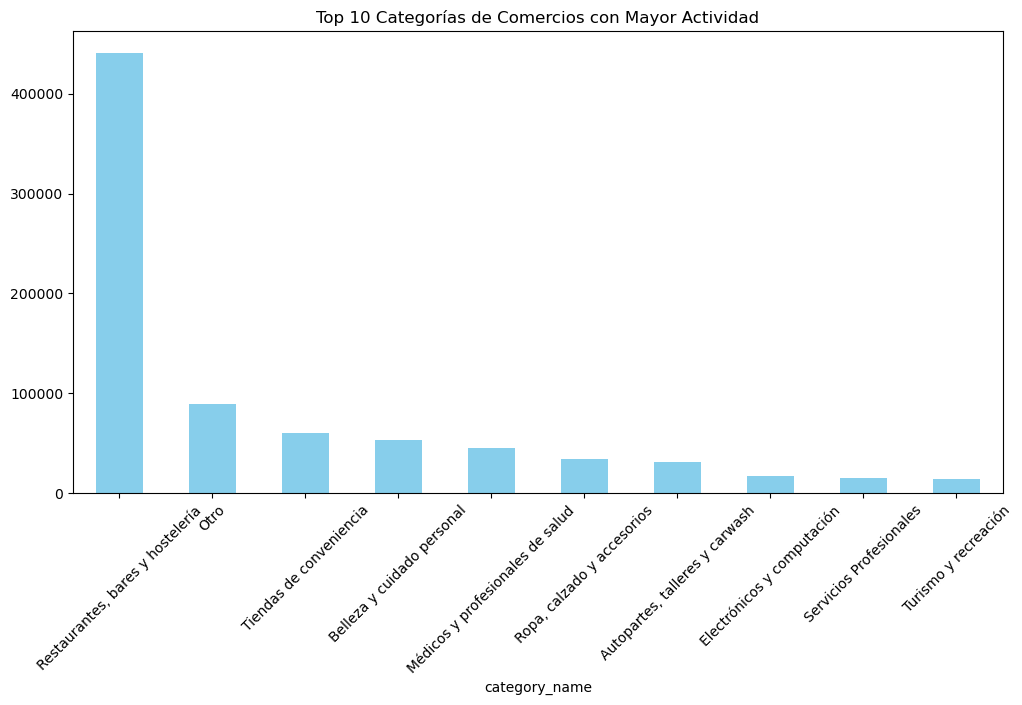

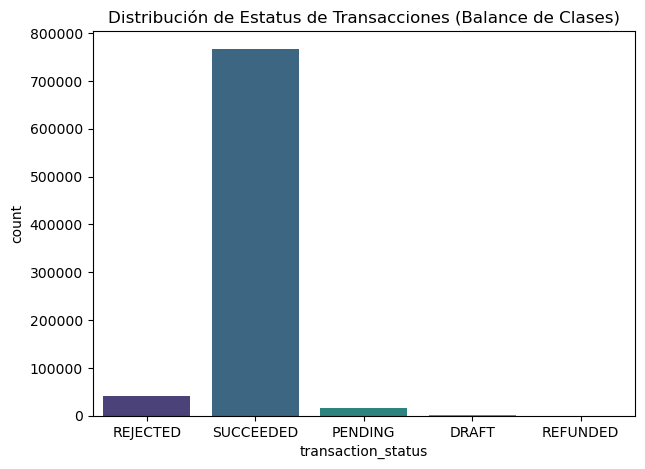

In [13]:

# B. Identificación de Outliers (Boxplot)
plt.figure(figsize=(10, 4))
sns.boxplot(x=filtered_amount, showfliers=True) # showfliers=False oculta los puntos extremos
plt.title('Detección de Valores Atípicos en Amount (IQR: Percentil 1 al 99)')
plt.xlabel('Monto ($)')
plt.show()

# C. Análisis de Valores Faltantes
missing_stats = df.isnull().sum()
missing_percent = (missing_stats / len(df)) * 100
print("Estadísticas de Valores Faltantes:")
print(pd.DataFrame({'Total Nulos': missing_stats, 'Porcentaje (%)': missing_percent}).sort_values(by='Total Nulos', ascending=False))

# --- ANÁLISIS MULTIVARIADO (Relación Inicial) ---

# D. Análisis de transacciones por categoría
plt.figure(figsize=(12, 6))
df['category_name'].value_counts().head(10).plot(kind='bar', color='skyblue')
plt.title('Top 10 Categorías de Comercios con Mayor Actividad')
plt.xticks(rotation=45)
plt.show()

# E. Análisis de Clases (Balance de Clases en Status)
# Esto justifica el manejo de desbalance que hacemos después
plt.figure(figsize=(7, 5))
sns.countplot(x='transaction_status', data=df, palette='viridis')
plt.title('Distribución de Estatus de Transacciones (Balance de Clases)')
plt.show()


## Insights de Valores Faltantes (Sección 3.1)
rejection_reason (95.08%): Este alto porcentaje de nulos es positivo y esperado, ya que indica transacciones exitosas que no requirieron un motivo de rechazo.

Decisión: No se eliminará la columna; los nulos se tratarán como una categoría "Succeeded" o "None" en el preprocesamiento, ya que la ausencia de rechazo es una señal clave de salud del comercio.

tag (72.36%), state_name y city_name (~58.6%): Existe una carencia importante de datos geográficos y etiquetas manuales.

Decisión: Dado que perderíamos más de la mitad de los datos si eliminamos filas, optaremos por la Imputación por Categoría Faltante (creando la etiqueta "Unknown"). Esto evita el sesgo de eliminar comercios de los cuales simplemente no tenemos ubicación.

Columnas Críticas (0%): Variables vitales como amount, company_id y trx_created_at están completas, lo que garantiza la integridad de nuestro cálculo de Churn y las variables de velocidad.

# Analasis Exploratorio de Datos (EDA) para transacciones crudas

Antes de analizar los datos crudos de las transacciones, debemos de limpiar ciertos registros que pueden ensuciar el analisis.
Existen comercios con montos igual a 0, los cuales se refieren a errores ingresados por los comercios a la hora de cobrar, o unicamente son pruebas que realizan. Transacciones con montos negativos se refieren a reembolsos o cancelaciones. Para el analisis de churn, se considerarán solo transacciones con montos positivos, ya que reflejan actividad real de los comercios. Por eso limpiaremos esas transacciones previo a cualquier analisis

In [14]:
#Limpiamos registros donde amount sea menor o igual a 0
df = df[df["amount"] > 0].copy()

In [15]:
print("Shape:", df.shape)
print("Columns:", list(df.columns))

print("\nDtypes:")
print(df.dtypes)

print("\nRango trx_created_at:")
print(df["trx_created_at"].min(), "→", df["trx_created_at"].max())

print("\nComercios únicos:", df["company_id"].nunique())


Shape: (822776, 13)
Columns: ['company_id', 'company_created_at', 'trx_created_at', 'amount', 'transaction_type', 'transaction_status', 'rejection_reason', 'category_name', 'state_name', 'city_name', 'kyc_level', 'tag', 'is_taxpayer']

Dtypes:
company_id                       str
company_created_at    datetime64[ns]
trx_created_at        datetime64[ns]
amount                       float64
transaction_type                 str
transaction_status               str
rejection_reason                 str
category_name                    str
state_name                       str
city_name                        str
kyc_level                        str
tag                          float64
is_taxpayer                     bool
dtype: object

Rango trx_created_at:
2025-01-01 00:01:26.543000 → 2025-12-31 23:52:00.691000

Comercios únicos: 10788


In [16]:
print("\ntransaction_status (top):")
print(df["transaction_status"].value_counts(dropna=False).head(20))

print("\ntransaction_type (top):")
print(df["transaction_type"].value_counts(dropna=False).head(20))

print("\ncategory_name (top):")
print(df["category_name"].value_counts(dropna=False).head(20))



transaction_status (top):
transaction_status
SUCCEEDED    766846
REJECTED      40469
PENDING       15183
DRAFT           278
Name: count, dtype: int64

transaction_type (top):
transaction_type
POS                        763001
LINK                        47566
POS-MSI                      4110
LINK-MSI                     3687
QR                           2667
REUSABLE-WITH-AMOUNT          622
SUBSCRIPTION                  505
REUSABLE-WITHOUT-AMOUNT       449
QR-MSI                        130
LINK-API                       25
API                            11
POS-API                         3
Name: count, dtype: int64

category_name (top):
category_name
Restaurantes, bares y hostelería       440672
Otro                                    89135
Tiendas de conveniencia                 60296
Belleza y cuidado personal              52775
Médicos y profesionales de salud        45263
Ropa, calzado y accesorios              33789
Autopartes, talleres y carwash          30658
Electrónicos y

In [17]:
print("\namount stats (raw):")
print(df["amount"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))

print("\namount <= 0:", (df["amount"] <= 0).sum())
print("amount is null:", df["amount"].isna().sum())



amount stats (raw):
count    822776.00
mean         52.04
std        8597.04
min           0.01
50%          13.21
75%          30.00
90%          70.97
95%         130.00
99%         500.00
max     7757757.75
Name: amount, dtype: float64

amount <= 0: 0
amount is null: 0


In [18]:
missing = df.isna().mean().sort_values(ascending=False) * 100
missing_df = pd.DataFrame({
    "missing_pct": missing.round(2),
    "missing_count": df.isna().sum()
}).sort_values("missing_pct", ascending=False)

missing_df


,missing_pct,missing_count
rejection_reason,95.08,782322
tag,72.36,595375
state_name,58.67,482717
city_name,58.67,482717
amount,0.00,0
company_id,0.00,0
company_created_at,0.00,0
category_name,0.00,0
kyc_level,0.00,0
is_taxpayer,0.00,0


Vemos que la cantidad de Nulos en razon de rechazo es grande, debido a que más del 90% de las transaccines son SUCCEEDED, y solo las REJECTED tienen un motivo de rechazo. Sin embargo, se debe de dar enfasis que la razon de rechazo no se utilizará como feature para predecir el churn, ya que solo estará presente en las transacciones rechazadas, lo que podría introducir un sesgo significativo en el modelo. En cambio, se podrían crear features binarias indicando si una transacción fue rechazada o no, sin entrar en detalles de la razón específica.

Tag se presenta como nulo cuando no hay un vendedor asignado a ese comercio, lo cual solo nos sirve para categorizar el canal al que pertenece el comercio.

City y state tiene un porcentaje nulo bastante alto y no se utilizarán dentro del análisis, la razón es porque el roll out de segmentación geográfica se hizo de manera gradual, por lo que los comercios más antiguos no tienen esta información.

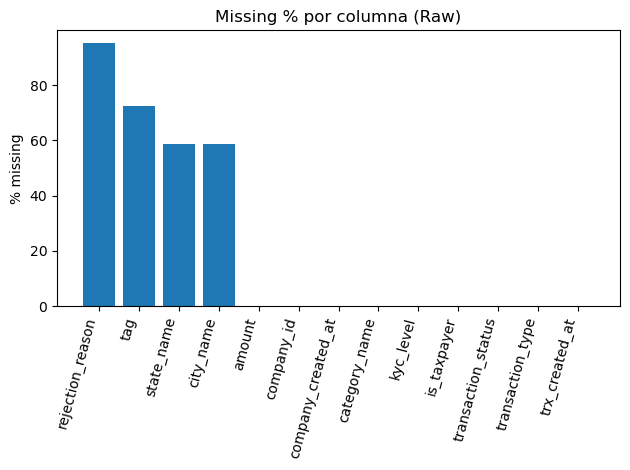

In [19]:
plt.figure()
plt.bar(missing_df.index, missing_df["missing_pct"])
plt.title("Missing % por columna (Raw)")
plt.xticks(rotation=75, ha="right")
plt.ylabel("% missing")
plt.tight_layout()
plt.show()


Para analisis de montos , se deben de considerar solo las que sean SUCCEEDED, ya que las rechazadas o pendientes no reflejan actividad real de los comercios. Por eso se limpiarán esas transacciones previo a cualquier analisis de montos. Estos valores igualmente pueden representar error al escribir los montos durante los cobros. Veamos la siguiente imagen a continuación para entender mejor la distribución de los montos.

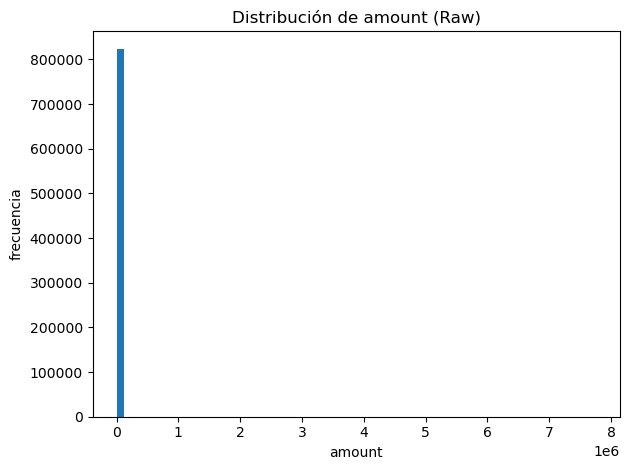

In [20]:
#Si vemos la distribucion cruda
plt.figure()
plt.hist(df["amount"].dropna(), bins=60)
plt.title("Distribución de amount (Raw)")
plt.xlabel("amount")
plt.ylabel("frecuencia")
plt.tight_layout()
plt.show()


el histograma se mira extremadamente sesgado a la derecha, con una gran cantidad de transacciones pequeñas y unas pocas transacciones muy grandes. Para visualizar mejor la distribución, se puede aplicar una transformación logarítmica a los montos, lo que ayudará a reducir el efecto de los valores extremos y a mostrar con mayor claridad la distribución de las transacciones más pequeñas.

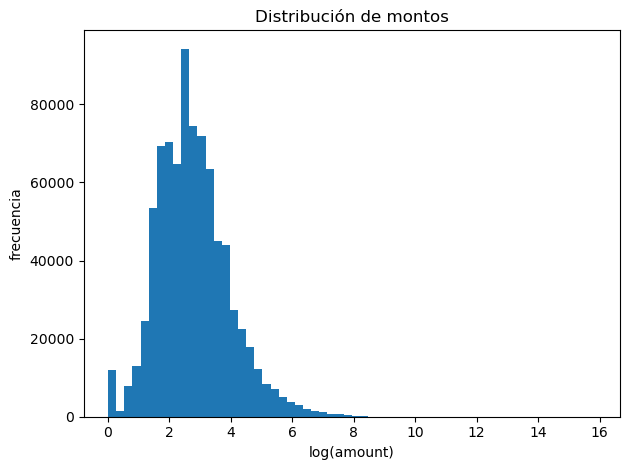

In [21]:

plt.figure()
plt.hist(np.log1p(df['amount']), bins=60)
plt.title("Distribución de montos")
plt.xlabel("log(amount)")
plt.ylabel("frecuencia")
plt.tight_layout()
plt.show()


Vemos como la distribucion está extremadamente sesgada a la derecha. Esto es común en datos de transacciones, donde la mayoría de las transacciones son de montos pequeños, asi que debemos de limpiar las que no sean SUCCEEDED para analizar montos

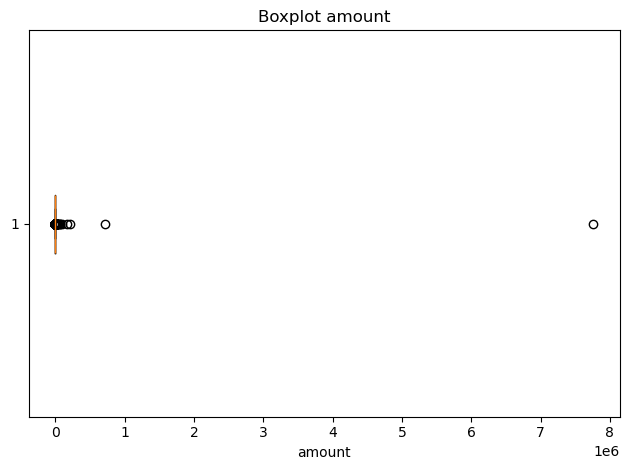

In [22]:
plt.figure()
plt.boxplot(df['amount'], vert=False)
plt.title("Boxplot amount")
plt.xlabel("amount")
plt.tight_layout()
plt.show()


Volvemos a generar las mismas 3 graficas pero solo con las transacciones SUCCEEDED, para entender mejor la distribucion de los montos reales de los comercios

In [23]:
df_succ = df[df["transaction_status"] == "SUCCEEDED"].copy()

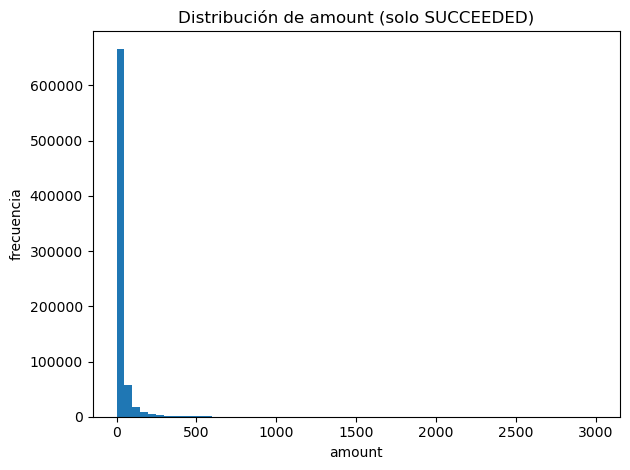

count   766846.00
mean        34.38
std        103.00
min          0.01
50%         13.00
75%         29.50
90%         65.00
95%        112.00
99%        379.71
max       3000.00
Name: amount, dtype: float64

In [24]:
plt.figure()
plt.hist(df_succ["amount"].dropna(), bins=60)
plt.title("Distribución de amount (solo SUCCEEDED)")
plt.xlabel("amount")
plt.ylabel("frecuencia")
plt.tight_layout()
plt.show()

df_succ["amount"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])


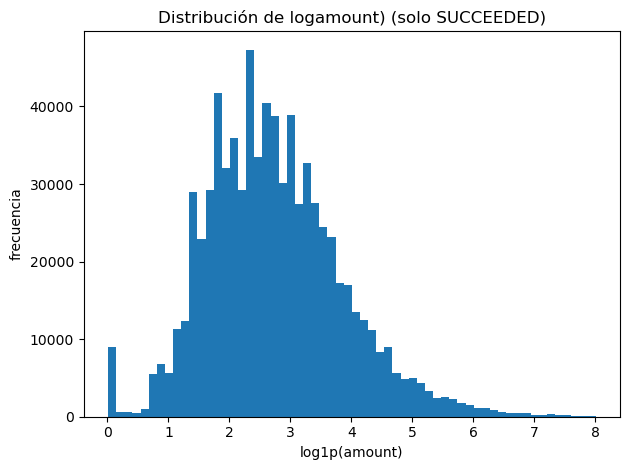

In [25]:
plt.figure()
plt.hist(np.log1p(df_succ["amount"].dropna()), bins=60)
plt.title("Distribución de logamount) (solo SUCCEEDED)")
plt.xlabel("log1p(amount)")
plt.ylabel("frecuencia")
plt.tight_layout()
plt.show()


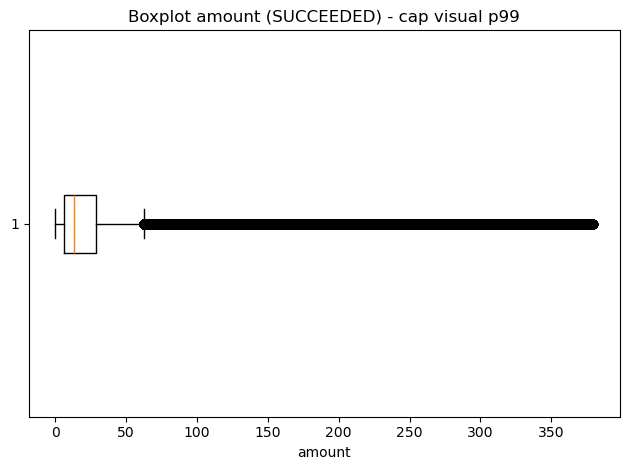

p99 cap: 379.7080000000074


In [26]:
vals = df_succ["amount"].dropna()
cap = vals.quantile(0.99)
vals_plot = vals[vals <= cap]

plt.figure()
plt.boxplot(vals_plot, vert=False)
plt.title("Boxplot amount (SUCCEEDED) - cap visual p99")
plt.xlabel("amount")
plt.tight_layout()
plt.show()

print("p99 cap:", cap)


In [27]:
#Rango intercuartílico de amount
amount_q1 = df_succ["amount"].quantile(0.25)
amount_q3 = df_succ["amount"].quantile(0.75)
amount_iqr = amount_q3 - amount_q1
amount_lower_bound = amount_q1 - 1.5 * amount_iqr
amount_upper_bound = amount_q3 + 1.5 * amount_iqr
print("Amount IQR:", amount_iqr)
print("Amount lower bound:", amount_lower_bound)
print("Amount upper bound:", amount_upper_bound)


Amount IQR: 23.5
Amount lower bound: -29.25
Amount upper bound: 64.75


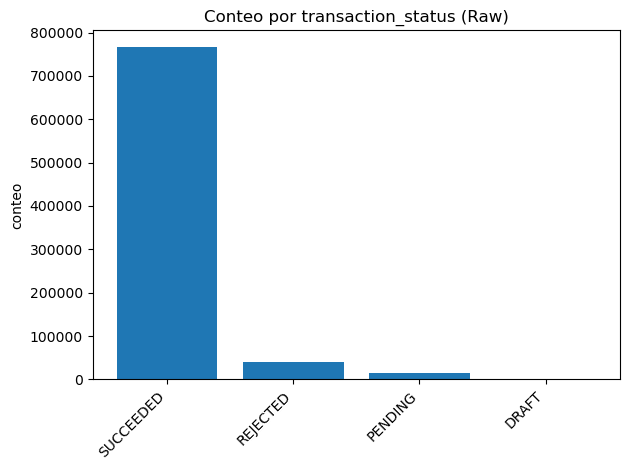

transaction_status
SUCCEEDED   93.20
REJECTED     4.92
PENDING      1.85
DRAFT        0.03
Name: count, dtype: float64


In [28]:
status_counts = df["transaction_status"].value_counts(dropna=False)
plt.figure()
plt.bar(status_counts.index.astype(str), status_counts.values)
plt.title("Conteo por transaction_status (Raw)")
plt.xticks(rotation=45, ha="right")
plt.ylabel("conteo")
plt.tight_layout()
plt.show()

print((status_counts / len(df) * 100).round(2))


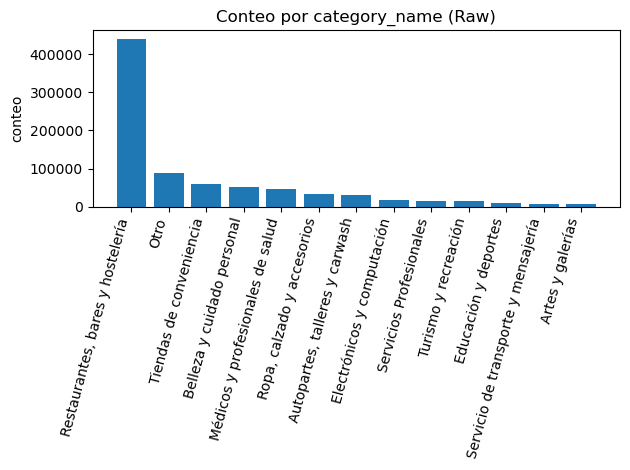

In [29]:
cat_counts = df["category_name"].value_counts()
plt.figure()
plt.bar(cat_counts.index.astype(str), cat_counts.values)
plt.title("Conteo por category_name (Raw)")
plt.xticks(rotation=75, ha="right")
plt.ylabel("conteo")
plt.tight_layout()
plt.show()


In [30]:
print(df["is_taxpayer"].value_counts(dropna=False))
print((df["is_taxpayer"].value_counts(normalize=True)*100).round(2))


is_taxpayer
False    506492
True     316284
Name: count, dtype: int64
is_taxpayer
False   61.56
True    38.44
Name: proportion, dtype: float64


In [31]:
print("\nEjemplos de kyc_level:")
print(df["kyc_level"].dropna().astype(str).head(5).tolist())

print("\nkyc_level - valores únicos (top 20):")
print(df["kyc_level"].value_counts(dropna=False).head(20))



Ejemplos de kyc_level:
['{"level_1":true,"level_2":true,"level_3":false}', '{"level_1":true,"level_2":true,"level_3":false}', '{"level_1":true,"level_2":true,"level_3":false}', '{"level_1":true,"level_2":true,"level_3":false}', '{"level_1":true,"level_2":true,"level_3":false}']

kyc_level - valores únicos (top 20):
kyc_level
{"level_1":true,"level_2":true,"level_3":false}     800696
{"level_1":true,"level_2":false,"level_3":false}     22080
Name: count, dtype: int64


22082 comercios Poseen nivel 2 de KYC, los demas son KYC1. Esto indica que a gran mayoria de clientes no se les solicita documentación adicional para operar. Cabe mencionar que la base analizada no es de todos los clientes de la empresa sino de un segmento específico, por lo que no se puede generalizar esta conclusión a toda la base de clientes.

In [32]:
# Creamos nuevas columnas para mes de transaccion y flags de estado para facilitar analisis mensual y por estado
df_succ["trx_month"] = df_succ["trx_created_at"].dt.to_period("M").astype(str)
df["is_succeeded"] = (df["transaction_status"] == "SUCCEEDED").astype(int)
df["is_rejected"] = (df["transaction_status"] == "REJECTED").astype(int)
df["is_pending"] = (df["transaction_status"] == "PENDING").astype(int)


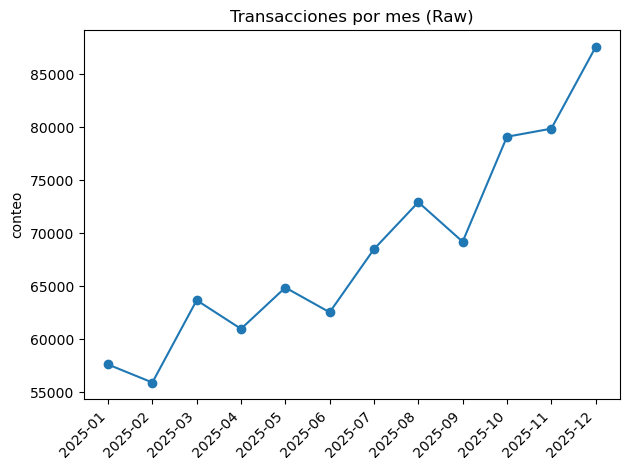

trx_month
2025-01    57620
2025-02    55920
2025-03    63680
2025-04    60980
2025-05    64877
2025-06    62544
2025-07    68502
2025-08    72930
2025-09    69199
2025-10    79103
2025-11    79864
2025-12    87557
dtype: int64

In [33]:
df["trx_month"] = df["trx_created_at"].dt.to_period("M").astype(str)
trx_by_month = df.groupby("trx_month").size()

plt.figure()
plt.plot(trx_by_month.index, trx_by_month.values, marker="o")
plt.title("Transacciones por mes (Raw)")
plt.xticks(rotation=45, ha="right")
plt.ylabel("conteo")
plt.tight_layout()
plt.show()

trx_by_month

Existe una pendiente significativa en diciembre, lo que indica mayor actividad transaccional en ese mes, por temporada navideña y vacaciones.

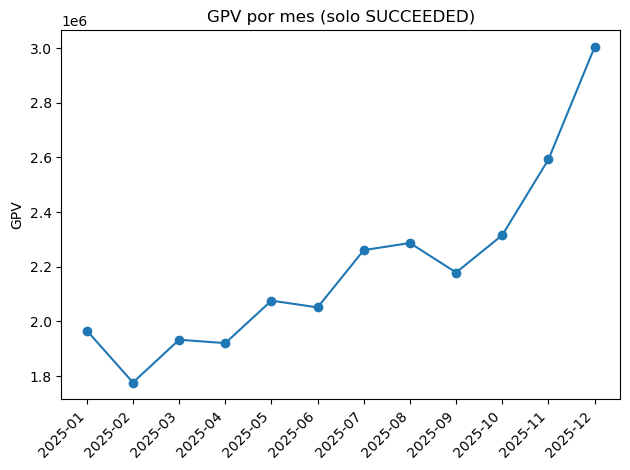

trx_month
2025-01   1966833.82
2025-02   1776617.81
2025-03   1933062.27
2025-04   1920684.83
2025-05   2076131.81
2025-06   2051435.42
2025-07   2261027.18
2025-08   2286978.91
2025-09   2179033.37
2025-10   2315864.89
2025-11   2592661.04
2025-12   3003723.70
Name: amount, dtype: float64

In [34]:
gpv_by_month = df.loc[df["transaction_status"] == "SUCCEEDED"].groupby("trx_month")["amount"].sum()

plt.figure()
plt.plot(gpv_by_month.index, gpv_by_month.values, marker="o")
plt.title("GPV por mes (solo SUCCEEDED)")
plt.xticks(rotation=45, ha="right")
plt.ylabel("GPV")
plt.tight_layout()
plt.show()

gpv_by_month


Octubre a Diciembre son los meses con mayor GPV lo que coincide con la temporada alta de ventas.

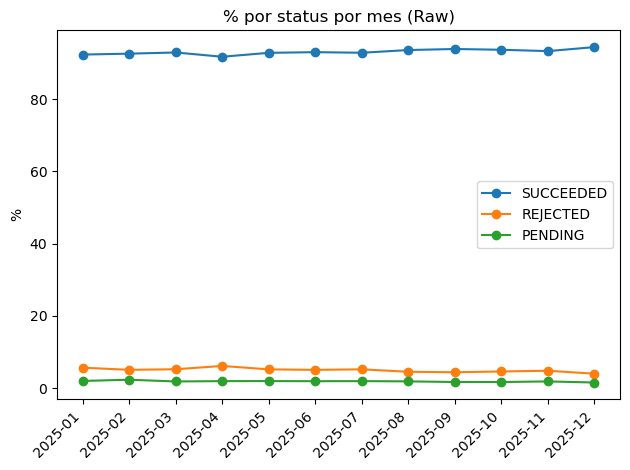

transaction_status,SUCCEEDED,REJECTED,PENDING
trx_month,,,
2025-01,92.37,5.65,1.97
2025-02,92.63,5.05,2.31
2025-03,92.95,5.21,1.83
2025-04,91.77,6.13,1.92
2025-05,92.85,5.18,1.94
2025-06,93.04,5.04,1.91
2025-07,92.87,5.19,1.92
2025-08,93.63,4.51,1.85
2025-09,93.92,4.38,1.68


In [35]:
status_month = df.pivot_table(
    index="trx_month",
    columns="transaction_status",
    values="company_id",
    aggfunc="count",
    fill_value=0
)

status_month_pct = status_month.div(status_month.sum(axis=1), axis=0) * 100
status_month_pct = status_month_pct.sort_index()

# grafica líneas para 3 estados principales si existen
cols = [c for c in ["SUCCEEDED", "REJECTED", "PENDING"] if c in status_month_pct.columns]

plt.figure()
for c in cols:
    plt.plot(status_month_pct.index, status_month_pct[c].values, marker="o", label=c)
plt.title("% por status por mes (Raw)")
plt.xticks(rotation=45, ha="right")
plt.ylabel("%")
plt.legend()
plt.tight_layout()
plt.show()

status_month_pct[cols].round(2)


In [36]:
df.groupby("transaction_status")["amount"].describe(percentiles=[0.5,0.75,0.9,0.95,0.99]).round(2)


,count,mean,std,min,50%,75%,90%,95%,99%,max
transaction_status,,,,,,,,,,
DRAFT,278.00,33.10,79.04,0.01,9.50,31.50,57.63,152.00,470.09,600.00
PENDING,15183.00,172.90,1127.42,0.01,30.00,100.00,348.00,700.00,2400.00,88500.26
REJECTED,40469.00,341.50,38754.49,0.01,16.50,50.68,240.00,545.99,2000.00,7757757.75
SUCCEEDED,766846.00,34.38,103.00,0.01,13.00,29.50,65.00,112.00,379.71,3000.00


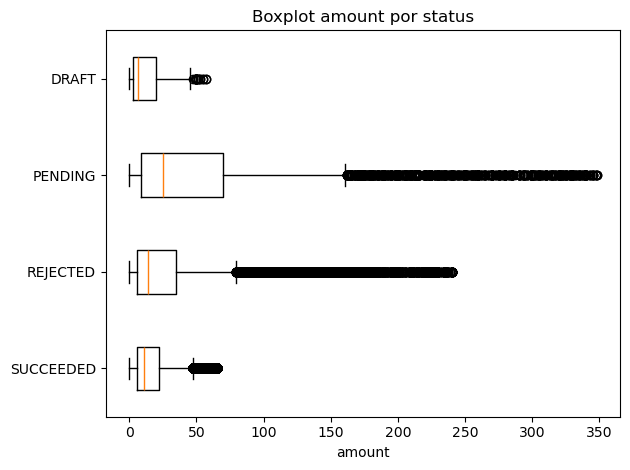

In [37]:
main_status = df["transaction_status"].value_counts().index.tolist()
data = []
labels = []
for s in main_status:
    vals = df.loc[(df["transaction_status"] == s), "amount"].dropna()
    # para evitar boxplot ilegible por outliers extremos, cap al p90 solo para la visual
    cap = vals.quantile(0.90) if len(vals) else None
    vals_plot = vals[vals <= cap] if cap is not None else vals
    data.append(vals_plot)
    labels.append(s)

plt.figure()
plt.boxplot(data, labels=labels, vert=False)
plt.title("Boxplot amount por status")
plt.xlabel("amount")
plt.tight_layout()
plt.show()


Rejected rows: 40469

Top rejection_reason:
rejection_reason
51 - FONDOS INSUFICIENTES                                16960
Por favor intenta con lectura por NFC o CHIP              2877
12 - TRANSACCION INVALIDA                                 2080
05 - LLAMAR AL EMISOR                                     1617
78 - undefined                                            1463
59 - SOSPECHA DE FRAUDE                                   1257
65 - MAXIMO PERMITIDO ALCANZADO                           1247
No hay resultados                                         1033
46 - undefined                                             965
57 - TRANSACCION NO PERMITIDA                              953
91 - EMISOR NO DISPONIBLE                                  928
Tarjeta no soportada para pago de meses sin intereses      800
ERROR DE COMUNICACION                                      708
62 - TARJETA RESTRINGIDA                                   659
61 - ACTIVIDAD DE LIMITE EXCEDIDO                        

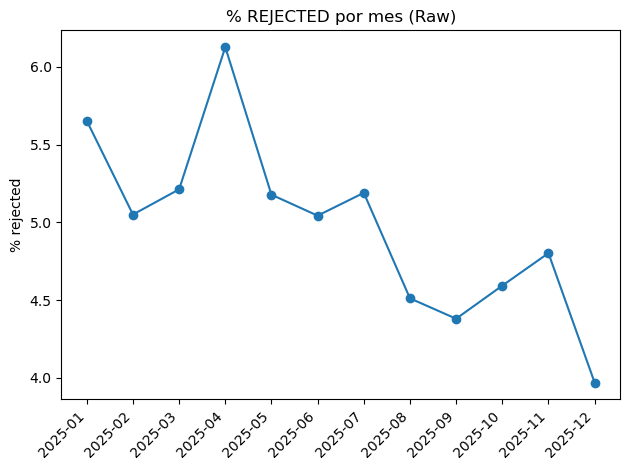

In [38]:
rej = df.loc[df["transaction_status"] == "REJECTED", "rejection_reason"]
print("Rejected rows:", len(rej))
print("\nTop rejection_reason:")
print(rej.value_counts(dropna=False).head(20))

# evolución mensual de rejected
rej_by_month = df.loc[df["transaction_status"] == "REJECTED"].groupby("trx_month").size()
tot_by_month = df.groupby("trx_month").size()
rej_rate = (rej_by_month / tot_by_month * 100).fillna(0)

plt.figure()
plt.plot(rej_rate.index, rej_rate.values, marker="o")
plt.title("% REJECTED por mes (Raw)")
plt.xticks(rotation=45, ha="right")
plt.ylabel("% rejected")
plt.tight_layout()
plt.show()


Diciembre presentó el mes con menos cantidad de transacciones Rechazadas.
La razon de rechazo mas comun son los fondos insuficientes

In [39]:
missing_df.head(10
)

,missing_pct,missing_count
rejection_reason,95.08,782322
tag,72.36,595375
state_name,58.67,482717
city_name,58.67,482717
amount,0.00,0
company_id,0.00,0
company_created_at,0.00,0
category_name,0.00,0
kyc_level,0.00,0
is_taxpayer,0.00,0


In [40]:
df["transaction_type"].value_counts()

transaction_type
POS                        763001
LINK                        47566
POS-MSI                      4110
LINK-MSI                     3687
QR                           2667
REUSABLE-WITH-AMOUNT          622
SUBSCRIPTION                  505
REUSABLE-WITHOUT-AMOUNT       449
QR-MSI                        130
LINK-API                       25
API                            11
POS-API                         3
Name: count, dtype: int64

## Conlusiones del EDA a nivel transaccional

Las visualizaciones de relación feature–target, balance de clases y correlaciones se realizan tras construir el panel mensual, ya que la variable objetivo se define a nivel mensual.

- La mayoría de las transacciones son exitosas (SUCCEEDED) en promedio arriba del 94% mes a mes, con un porcentaje menor de transacciones rechazadas (REJECTED) y pendientes (PENDING).
- La distribución de los montos de las transacciones es altamente sesgada a la derecha, con una gran cantidad de transacciones pequeñas y unas pocas transacciones muy grandes. Esto es común en datos de transacciones y sugiere que la mayoría de los comercios realizan transacciones de bajo monto, mientras que unos pocos realizan transacciones de alto monto. Tambien el conjunto de datos provistos son una muestra de un segmento específico de clientes, por lo que no se pueden generalizar estas conclusiones a toda la base de clientes de la empresa.
- Existe una estacionalidad clara en la actividad transaccional, con un aumento significativo en diciembre, lo que coincide con la temporada navideña y de vacaciones
- La mayoría de los comercios tienen un nivel de KYC 1
- Las columnas de city y state tienen un alto porcentaje de valores nulos, por lo que se eliminarán del análisis, ya que no aportan información relevante para el modelo de churn.
- La razón de rechazo más común en las transacciones rechazadas es "fondos insuficientes"

# Manipulacion de datos para construir panel mensual a nivel comercio y definir target de churn

In [41]:
df_raw = df.copy()

# Asegurar que tag sea NaN real si vino como string raro (por si acaso)
df_raw["tag"] = df_raw["tag"].replace(["nan", "None", ""], np.nan)

# Month key para agrupar por mes
df_raw["trx_month"] = df_raw["trx_created_at"].dt.to_period("M")

# Flags por status
df_raw["is_succeeded"] = (df_raw["transaction_status"] == "SUCCEEDED").astype(int)
df_raw["is_rejected"]  = (df_raw["transaction_status"] == "REJECTED").astype(int)
df_raw["is_pending"]   = (df_raw["transaction_status"] == "PENDING").astype(int)

# Amount válido para GPV (solo succeeded y > 0)
df_raw["amount_succ"] = np.where(
    (df_raw["transaction_status"] == "SUCCEEDED") & (df_raw["amount"] > 0),
    df_raw["amount"],
    0.0
)

# Channel (Outbound si tiene tag)
df_raw["channel"] = np.where(df_raw["tag"].isna(), "Inbound", "Outbound")

In [42]:
df_raw.sample(10)

,company_id,company_created_at,trx_created_at,amount,transaction_type,transaction_status,rejection_reason,category_name,state_name,city_name,kyc_level,tag,is_taxpayer,is_succeeded,is_rejected,is_pending,trx_month,amount_succ,channel
145311,32941,2024-11-27 09:17:49.426112,2025-03-16 01:55:21.721,88.40,POS,SUCCEEDED,NaN,Electrónicos y computación,Sonsonate,Acajutla,"{""level_1"":true,""level_2"":true,""level_3"":false}",NaN,False,1,0,0,2025-03,88.40,Inbound
137535,20725,2024-03-18 13:26:33.158662,2025-03-12 18:40:15.614,40.25,POS,SUCCEEDED,NaN,"Restaurantes, bares y hostelería",NaN,NaN,"{""level_1"":true,""level_2"":true,""level_3"":false}",NaN,False,1,0,0,2025-03,40.25,Inbound
527266,33094,2024-11-30 10:36:54.750004,2025-09-10 14:50:10.578,6.25,POS,SUCCEEDED,NaN,"Restaurantes, bares y hostelería",San Salvador,San Salvador,"{""level_1"":true,""level_2"":true,""level_3"":false}",NaN,False,1,0,0,2025-09,6.25,Inbound
757609,41658,2025-07-16 12:21:35.136358,2025-12-09 13:39:57.989,20.00,POS,SUCCEEDED,NaN,Otro,Santa Ana,El Congo,"{""level_1"":true,""level_2"":true,""level_3"":false}",32.00,True,1,0,0,2025-12,20.00,Outbound
292424,30154,2024-10-04 15:36:46.172983,2025-05-27 11:47:56.028,1.10,LINK,PENDING,NaN,Servicios Profesionales,San Salvador,San Salvador,"{""level_1"":true,""level_2"":true,""level_3"":false}",NaN,False,0,0,1,2025-05,0.00,Inbound
366505,12544,2023-07-25 10:05:33.117700,2025-07-01 14:13:35.776,7.50,POS,SUCCEEDED,NaN,"Restaurantes, bares y hostelería",NaN,NaN,"{""level_1"":true,""level_2"":true,""level_3"":false}",38.00,True,1,0,0,2025-07,7.50,Outbound
534420,8008,2022-11-22 12:16:56.528792,2025-09-13 13:31:15.285,32.00,POS,SUCCEEDED,NaN,Artes y galerías,NaN,NaN,"{""level_1"":true,""level_2"":true,""level_3"":false}",NaN,False,1,0,0,2025-09,32.00,Inbound
219595,27738,2024-08-21 13:21:43.376267,2025-04-21 13:23:13.870,10.00,POS,SUCCEEDED,NaN,"Restaurantes, bares y hostelería",NaN,NaN,"{""level_1"":true,""level_2"":true,""level_3"":false}",NaN,False,1,0,0,2025-04,10.00,Inbound
354053,4532,2022-07-13 11:35:21.599170,2025-06-26 06:10:11.470,2.10,POS,SUCCEEDED,NaN,Tiendas de conveniencia,NaN,NaN,"{""level_1"":true,""level_2"":true,""level_3"":false}",NaN,False,1,0,0,2025-06,2.10,Inbound
116563,33921,2024-12-18 12:57:43.400303,2025-03-01 21:30:36.112,53.29,POS,SUCCEEDED,NaN,"Restaurantes, bares y hostelería",San Vicente,Apastepeque,"{""level_1"":true,""level_2"":true,""level_3"":false}",143.00,False,1,0,0,2025-03,53.29,Outbound


In [43]:

# KYC: vamos a parsear el json que viene del KYC para sacar el nivel en el que el comercios se encuentra. En el EDA vimos que solo puede ser 1 o 2

def parse_kyc_max_level(x):
    if pd.isna(x):
        return np.nan
    try:
        d = json.loads(x) if isinstance(x, str) else x
        # Esperado: {"level_1":true,"level_2":true,"level_3":false}
        lvl = 0
        for k in ["level_1", "level_2", "level_3"]:
            if d.get(k) is True:
                lvl = max(lvl, int(k.split("_")[1]))
        return lvl if lvl > 0 else 0
    except Exception:
        return np.nan

df_raw["kyc_max_level"] = df_raw["kyc_level"].apply(parse_kyc_max_level)

In [44]:
df_raw[["kyc_level", "kyc_max_level"]].sample(10)

,kyc_level,kyc_max_level
115904,"{""level_1"":true,""level_2"":true,""level_3"":false}",2
621664,"{""level_1"":true,""level_2"":true,""level_3"":false}",2
605760,"{""level_1"":true,""level_2"":true,""level_3"":false}",2
482556,"{""level_1"":true,""level_2"":true,""level_3"":false}",2
252772,"{""level_1"":true,""level_2"":true,""level_3"":false}",2
287391,"{""level_1"":true,""level_2"":true,""level_3"":false}",2
104315,"{""level_1"":true,""level_2"":true,""level_3"":false}",2
794964,"{""level_1"":true,""level_2"":true,""level_3"":false}",2
779294,"{""level_1"":true,""level_2"":true,""level_3"":false}",2
9846,"{""level_1"":true,""level_2"":true,""level_3"":false}",2


In [45]:
df_raw.info()

<class 'pandas.DataFrame'>
Index: 822776 entries, 0 to 822784
Data columns (total 20 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   company_id          822776 non-null  str           
 1   company_created_at  822776 non-null  datetime64[ns]
 2   trx_created_at      822776 non-null  datetime64[ns]
 3   amount              822776 non-null  float64       
 4   transaction_type    822776 non-null  str           
 5   transaction_status  822776 non-null  str           
 6   rejection_reason    40454 non-null   str           
 7   category_name       822776 non-null  str           
 8   state_name          340059 non-null  str           
 9   city_name           340059 non-null  str           
 10  kyc_level           822776 non-null  str           
 11  tag                 227401 non-null  float64       
 12  is_taxpayer         822776 non-null  bool          
 13  is_succeeded        822776 non-null  int64   

Definimos variables estaticas relacionadas al comercios, como su fecha de creación, categoría, canal, si es contribuyente o no, y su nivel máximo de KYC. Estas variables se agrupan a nivel de comercio (company_id) tomando la fecha de creación mínima, la moda para categoría y canal, el valor booleano más común para is_taxpayer, y el nivel máximo para kyc_max_level.

Se trabajan modas porque al ser un registro por comercio, puede haber cambios en la categoría o canal a lo largo del tiempo, por lo que se toma la moda para representar la categoría o canal más frecuente del comercio. Para is_taxpayer se hace algo similar pero tomando el valor booleano más común (True o False) para determinar si el comercio es contribuyente o no. Para kyc_max_level se toma el nivel máximo alcanzado por el comercio, ya que esto refleja el nivel de cumplimiento más alto que ha tenido.

In [46]:

def mode_or_nan(s):
    s = s.dropna()
    return s.mode().iloc[0] if len(s.mode()) else np.nan

dim_company = df_raw.groupby("company_id").agg(
    company_created_at=("company_created_at", "min"),
    category_name=("category_name", mode_or_nan),
    channel=("channel", mode_or_nan),
    is_taxpayer=("is_taxpayer", lambda x: bool(mode_or_nan(x.astype(int)))),
    kyc_max_level=("kyc_max_level", "max"),
).reset_index()

Agregacion mensual por company_id y trx_month para construir el panel mensual.

In [47]:
monthly = df_raw.groupby(["company_id", "trx_month"]).agg(
    gpv_month=("amount_succ", "sum"),
    trx_total=("company_id", "size"),
    trx_succeeded=("is_succeeded", "sum"),
    trx_rejected=("is_rejected", "sum"),
    trx_pending=("is_pending", "sum"),
    avg_ticket=("amount_succ", lambda x: (x[x > 0].mean() if (x > 0).any() else 0.0)),
).reset_index()

Ya que no todos los comercios tienen transacciones en todos los meses, es necesario completar los meses sin transacciones para cada comercio, creando un panel completo a nivel de company_id y trx_month. Esto se hace generando un grid con todas las combinaciones posibles de company_id y meses del año 2025, y luego haciendo un merge con el dataframe mensual para llenar los valores faltantes. Para los meses sin transacciones, se rellenan las métricas mensuales con 0, ya que la ausencia de transacciones implica que no hubo actividad en ese mes.

In [48]:

months_2025 = pd.period_range("2025-01", "2025-12", freq="M")
companies = dim_company["company_id"].unique()

grid = pd.MultiIndex.from_product([companies, months_2025], names=["company_id", "trx_month"]).to_frame(index=False)

panel = grid.merge(monthly, on=["company_id", "trx_month"], how="left")

# Relleno de 0s en métricas mensuales (mes sin trx = 0)
fill_zero_cols = ["gpv_month", "trx_total", "trx_succeeded", "trx_rejected", "trx_pending", "avg_ticket"]
for c in fill_zero_cols:
    panel[c] = panel[c].fillna(0)

# Agregar dimensiones estáticas
panel = panel.merge(dim_company, on="company_id", how="left")

**Calculo de Churn**

Para definir si un comercio cae en churn se aplican 2 reglas de negocio:

**Base Activa (Umbral Fijo)**
Definimos un activo por regla de negocio como aquel comercio que en el mes t transacciona un monto igual o superior a $15 USD. Por lo que si el comercio transacciona menos de ese monto se considera inactivo y no se tomará en cuenta el análisis.

**Condicion Churn Soft (Caida del 85% de las ventas)**
Se define una regla de negocio que detecta una caida en las ventas de un mes t con respecto al siguiente t+1. Si la caida es mayor al 85% (Caida Fuerte) esto se considera comercio con intenciones de abandono.

Para definir el churn, se compara la actividad del mes t con la del mes t+1, creando una variable "churn_next" que indica si un comercio activo en el mes t se volvió inactivo o presentó una caída en ventas de mas del 85%en el mes t+1. Se ordena el panel por company_id y trx_month para asegurar que la comparación entre meses sea correcta, y se maneja el caso de diciembre de 2025 para evitar tener un mes t+1 sin datos.

In [49]:
ACTIVE_GPV_THRESHOLD = 15.0
panel["active_month"] = (panel["gpv_month"] >= ACTIVE_GPV_THRESHOLD).astype(int)

# Ordenamos para asegurar que el 'futuro' sea el mes siguiente
panel = panel.sort_values(["company_id", "trx_month"])

# 1. Traemos el MONTO del mes siguiente (no solo el estado activo ya que quiero saber si tuvo una caida considerable)
panel["gpv_next"] = panel.groupby("company_id")["gpv_month"].shift(-1)

# 2. Definimos las dos condiciones de abandono
# A. Hard Churn: Venta futura menor al umbral (lógica original)
condicion_hard = panel["gpv_next"] < ACTIVE_GPV_THRESHOLD

# B. Soft Churn: Caída dramática (>= 85%) en comercios que vendían bien
#    (Venta futura <= 15% de la actual) Y (Venta actual >= 15)
condicion_soft = (panel["gpv_next"] <= (panel["gpv_month"] * 0.15)) & (panel["gpv_month"] >= ACTIVE_GPV_THRESHOLD)

# 3. Combinamos: Es Churn si cumple A O cumple B
panel["churn_next"] = np.where(condicion_hard | condicion_soft, 1, 0)
# -----------------------------

# No usamos diciembre como t (porque no hay t+1 en 2025)
panel["month_str"] = panel["trx_month"].astype(str)
panel = panel[panel["trx_month"] < pd.Period("2025-12", freq="M")].copy()

#ya no usaria active next en este caso lo voy a comentariar
# panel["active_next"] = (panel["gpv_next"] >= ACTIVE_GPV_THRESHOLD).astype(int)


## Metodologia
Consistencia Temporal: Se aplica un ordenamiento por company_id y trx_month para garantizar que la función .shift(-1) capture efectivamente el mes cronológico siguiente.
Prevención de Sesgo (Diciembre): Se elimina diciembre de 2025 como mes base ($t$) debido a que la ausencia de datos en enero 2026 generaría falsos positivos de Churn.
Definición de Target: La inclusión de Soft Churn (caída del 85%) permite al modelo aprender señales preventivas, no solo reactivas, lo cual es un requerimiento crítico del negocio para actuar antes de que el comercio cierre definitivamente.

In [50]:
# verificar si crece el %
print(panel["churn_next"].value_counts(normalize=True))

churn_next
1   0.65
0   0.35
Name: proportion, dtype: float64


Para las metricas temporales como GPV del mes anterior, transacciones del mes anterior, tasa de rechazo, cambio absoluto y relativo de GPV respecto al mes anterior, y rolling de 3 meses, se crean nuevas columnas utilizando funciones de shift y rolling dentro de cada company_id para calcular estas métricas.

In [51]:

panel["gpv_lag1"] = panel.groupby("company_id")["gpv_month"].shift(1).fillna(0)
panel["trx_succ_lag1"] = panel.groupby("company_id")["trx_succeeded"].shift(1).fillna(0)
panel["rejected_rate"] = np.where(panel["trx_total"] > 0, panel["trx_rejected"] / panel["trx_total"], 0.0)

panel["delta_gpv"] = panel["gpv_month"] - panel["gpv_lag1"]
panel["pct_change_gpv"] = np.where(panel["gpv_lag1"] > 0, panel["delta_gpv"] / panel["gpv_lag1"], 0.0)

# Rolling 3M (incluye mes actual)
panel["gpv_roll3"] = (
    panel.groupby("company_id")["gpv_month"]
    .rolling(window=3, min_periods=1)
    .sum()
    .reset_index(level=0, drop=True)
)

panel["trx_succ_roll3"] = (
    panel.groupby("company_id")["trx_succeeded"]
    .rolling(window=3, min_periods=1)
    .sum()
    .reset_index(level=0, drop=True)
)

Un campo importante es el de Recency, el cual mide la cantidad de días desde la última transacción exitosa (SUCCEEDED) hasta el final del mes t. Para calcular esta métrica, se identifica la fecha de la última transacción exitosa para cada comercio en cada mes, y luego se calcula la diferencia en días entre esa fecha y el último día del mes t. Si un comercio no ha tenido transacciones exitosas hasta ese mes, se puede dejar como NaN o imputar un valor alto por ejemplo, 9999 para indicar que no ha habido actividad reciente.

In [52]:

# Última fecha SUCCEEDED por company y mes
df_succ = df_raw[(df_raw["transaction_status"] == "SUCCEEDED") & (df_raw["amount"] > 0)].copy()
last_succ_in_month = (
    df_succ.groupby(["company_id", "trx_month"])["trx_created_at"]
    .max()
    .reset_index()
    .rename(columns={"trx_created_at": "last_succ_date_in_month"})
)

panel = panel.merge(last_succ_in_month, on=["company_id", "trx_month"], how="left")

#cumulo hacia adelante para llenar la última fecha SUCCEEDED hasta el mes t
panel["last_succ_date_upto_t"] = (
    panel.groupby("company_id")["last_succ_date_in_month"]
    .ffill()
)

# Mes final para calcular recency
panel["month_end"] = panel["trx_month"].dt.to_timestamp("M")

panel["recency_days"] = (panel["month_end"] - panel["last_succ_date_upto_t"]).dt.days


La edad del comercio en días se calcula como la diferencia entre el último día del mes t y la fecha de creación del comercio. Esta métrica puede ser útil para entender si los comercios más nuevos tienen una mayor propensión al churn en comparación con los comercios más antiguos.

In [53]:

panel["merchant_age_days"] = (panel["month_end"] - panel["company_created_at"]).dt.days


In [54]:

# Quitamos columnas no necesarias para modelado final
panel = panel.drop(columns=["tag", "kyc_level", "state_name", "city_name"], errors="ignore")

In [55]:
panel.info()

<class 'pandas.DataFrame'>
RangeIndex: 118668 entries, 0 to 118667
Data columns (total 29 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   company_id               118668 non-null  str           
 1   trx_month                118668 non-null  period[M]     
 2   gpv_month                118668 non-null  float64       
 3   trx_total                118668 non-null  float64       
 4   trx_succeeded            118668 non-null  float64       
 5   trx_rejected             118668 non-null  float64       
 6   trx_pending              118668 non-null  float64       
 7   avg_ticket               118668 non-null  float64       
 8   company_created_at       118668 non-null  datetime64[ns]
 9   category_name            118668 non-null  str           
 10  channel                  118668 non-null  str           
 11  is_taxpayer              118668 non-null  bool          
 12  kyc_max_level            11

In [56]:

print("Panel shape:", panel.shape)
panel.head(10)

Panel shape: (118668, 29)


,company_id,trx_month,gpv_month,trx_total,trx_succeeded,trx_rejected,trx_pending,avg_ticket,company_created_at,category_name,...,rejected_rate,delta_gpv,pct_change_gpv,gpv_roll3,trx_succ_roll3,last_succ_date_in_month,last_succ_date_upto_t,month_end,recency_days,merchant_age_days
0,1,2025-01,214.96,2.00,2.00,0.00,0.00,107.48,2021-07-29 14:37:54.977033,Servicios Profesionales,...,0.00,214.96,0.00,214.96,2.00,2025-01-05 20:14:11.400,2025-01-05 20:14:11.400,2025-01-31,25.00,1281
1,1,2025-02,0.00,4.00,0.00,0.00,4.00,0.00,2021-07-29 14:37:54.977033,Servicios Profesionales,...,0.00,-214.96,-1.00,214.96,2.00,NaT,2025-01-05 20:14:11.400,2025-02-28,53.00,1309
2,1,2025-03,0.00,0.00,0.00,0.00,0.00,0.00,2021-07-29 14:37:54.977033,Servicios Profesionales,...,0.00,0.00,0.00,214.96,2.00,NaT,2025-01-05 20:14:11.400,2025-03-31,84.00,1340
3,1,2025-04,0.00,0.00,0.00,0.00,0.00,0.00,2021-07-29 14:37:54.977033,Servicios Profesionales,...,0.00,0.00,0.00,0.00,0.00,NaT,2025-01-05 20:14:11.400,2025-04-30,114.00,1370
4,1,2025-05,0.06,6.00,6.00,0.00,0.00,0.01,2021-07-29 14:37:54.977033,Servicios Profesionales,...,0.00,0.06,0.00,0.06,6.00,2025-05-09 05:10:01.891,2025-05-09 05:10:01.891,2025-05-31,21.00,1401
5,1,2025-06,0.02,10.00,2.00,8.00,0.00,0.01,2021-07-29 14:37:54.977033,Servicios Profesionales,...,0.80,-0.04,-0.67,0.08,8.00,2025-06-25 18:40:44.208,2025-06-25 18:40:44.208,2025-06-30,4.00,1431
6,1,2025-07,4.00,14.00,4.00,0.00,10.00,1.00,2021-07-29 14:37:54.977033,Servicios Profesionales,...,0.00,3.98,199.00,4.08,12.00,2025-07-15 14:02:02.967,2025-07-15 14:02:02.967,2025-07-31,15.00,1462
7,1,2025-08,0.00,0.00,0.00,0.00,0.00,0.00,2021-07-29 14:37:54.977033,Servicios Profesionales,...,0.00,-4.00,-1.00,4.02,6.00,NaT,2025-07-15 14:02:02.967,2025-08-31,46.00,1493
8,1,2025-09,0.00,0.00,0.00,0.00,0.00,0.00,2021-07-29 14:37:54.977033,Servicios Profesionales,...,0.00,0.00,0.00,4.00,4.00,NaT,2025-07-15 14:02:02.967,2025-09-30,76.00,1523
9,1,2025-10,0.00,0.00,0.00,0.00,0.00,0.00,2021-07-29 14:37:54.977033,Servicios Profesionales,...,0.00,0.00,0.00,0.00,0.00,NaT,2025-07-15 14:02:02.967,2025-10-31,107.00,1554


In [57]:
panel[["gpv_month","active_month","churn_next","trx_total","trx_rejected","rejected_rate"]].describe()

,gpv_month,active_month,churn_next,trx_total,trx_rejected,rejected_rate
count,118668.00,118668.00,118668.00,118668.00,118668.00,118668.00
mean,196.85,0.35,0.65,6.20,0.31,0.02
std,1293.26,0.48,0.48,30.03,1.51,0.11
min,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.00,0.00,0.00,0.00,0.00
50%,0.00,0.00,1.00,0.00,0.00,0.00
75%,75.48,1.00,1.00,3.00,0.00,0.00
max,112261.58,1.00,1.00,3488.00,58.00,1.00


In [58]:
print("Churn overall:", panel["churn_next"].mean()*100)
print("Churn base activa:", panel.loc[panel["active_month"]==1, "churn_next"].mean()*100)

print("Active months count:", (panel["active_month"]==1).sum())
print("Churn events count:", (panel["churn_next"]==1).sum())


Churn overall: 65.34954663430747
Churn base activa: 26.17528825554245
Active months count: 41543
Churn events count: 77549


# EDA a nivel de panel mensual con target

## PANEL COMPLETO

In [59]:
y_counts = panel["churn_next"].value_counts()
y_pct = panel["churn_next"].value_counts(normalize=True) * 100
print("Counts:\n", y_counts)
print("\nPercent:\n", y_pct.round(2))

Counts:
 churn_next
1    77549
0    41119
Name: count, dtype: int64

Percent:
 churn_next
1   65.35
0   34.65
Name: proportion, dtype: float64


In [60]:

# Solo base activa
y_counts_active = panel.loc[panel["active_month"]==1, "churn_next"].value_counts()
y_pct_active = panel.loc[panel["active_month"]==1, "churn_next"].value_counts(normalize=True) * 100
print("\nBase activa - Counts:\n", y_counts_active)
print("\nBase activa - Percent:\n", y_pct_active.round(2))



Base activa - Counts:
 churn_next
0    30669
1    10874
Name: count, dtype: int64

Base activa - Percent:
 churn_next
0   73.82
1   26.18
Name: proportion, dtype: float64


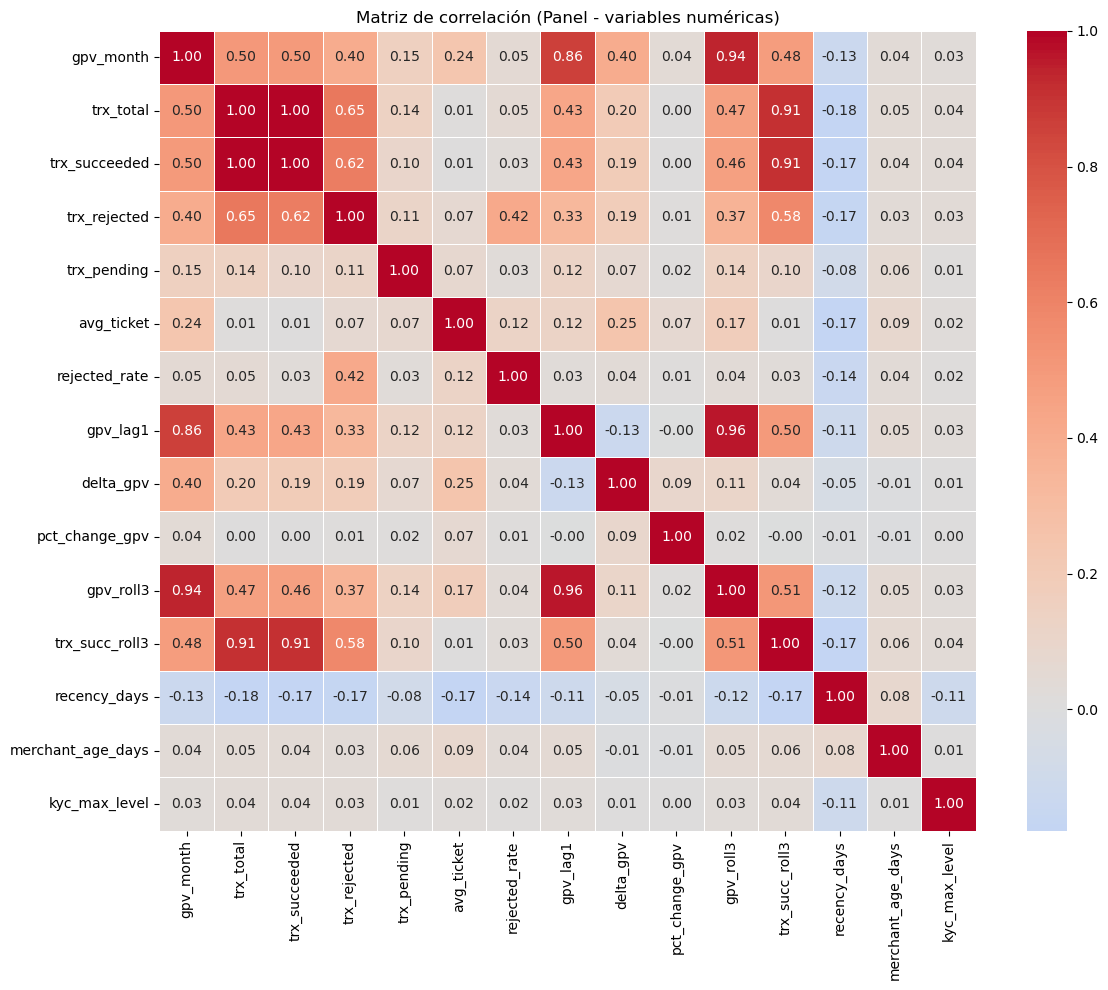

In [61]:


num_cols = [
    "gpv_month", "trx_total", "trx_succeeded", "trx_rejected", "trx_pending",
    "avg_ticket", "rejected_rate",
    "gpv_lag1", "delta_gpv", "pct_change_gpv",
    "gpv_roll3", "trx_succ_roll3",
    "recency_days", "merchant_age_days",
    "kyc_max_level"
]

corr = panel[num_cols].corr()

plt.figure(figsize=(12,10))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=True, fmt=".2f",
    linewidths=0.5
)
plt.title("Matriz de correlación (Panel - variables numéricas)")
plt.tight_layout()
plt.show()


Existe multicolinealidad esperada entre variables de volumen (trx_total, trx_succeeded) y sus agregaciones rolling. Recency_days tiene correlación negativa con gpv_month y trx_succeeded, lo que tiene sentido ya que a mayor recency (más días sin transacciones exitosas), menor GPV y menor cantidad de transacciones exitosas. Rejected_rate tiene correlación negativa con gpv_month y trx_succeeded, lo que también es lógico, ya que una mayor tasa de rechazo suele asociarse con menor actividad exitosa y menor GPV.

Hemos usado correlacion lineal de pearson, pero dado que algunas relaciones pueden ser no lineales, también se podrían explorar otras métricas de asociación o visualizaciones para entender mejor las relaciones entre variables.

In [62]:
group_means = panel.groupby("churn_next")[num_cols].mean(numeric_only=True).T
group_means.columns = ["NoChurn(0)", "Churn(1)"]
group_means["diff"] = group_means["Churn(1)"] - group_means["NoChurn(0)"]
group_means.sort_values("diff", ascending=False).head(15)


,NoChurn(0),Churn(1),diff
recency_days,12.83,84.94,72.11
rejected_rate,0.04,0.02,-0.02
kyc_max_level,1.95,1.90,-0.05
trx_pending,0.24,0.05,-0.19
trx_rejected,0.73,0.09,-0.65
trx_succeeded,15.09,0.82,-14.27
trx_total,16.07,0.96,-15.11
pct_change_gpv,71.11,50.15,-20.96
avg_ticket,48.00,18.53,-29.47
trx_succ_roll3,38.67,3.08,-35.59


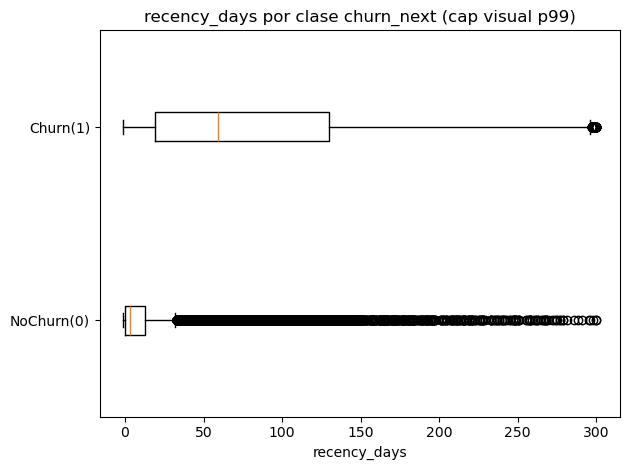

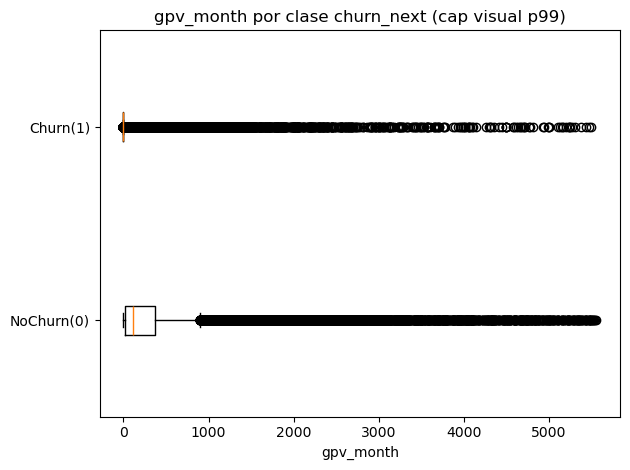

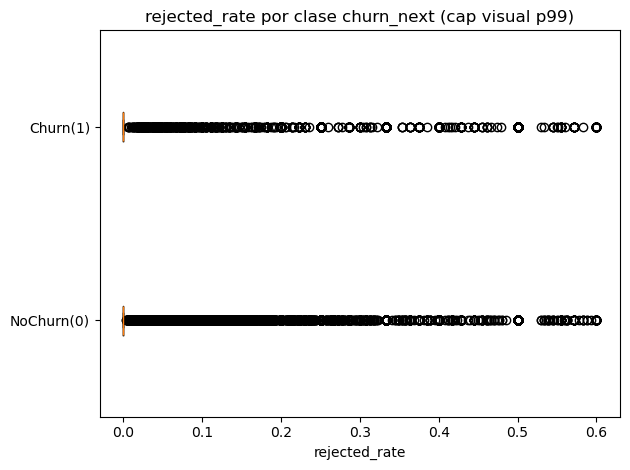

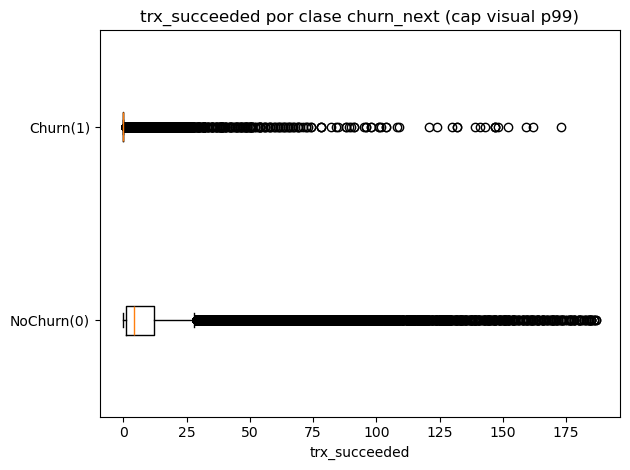

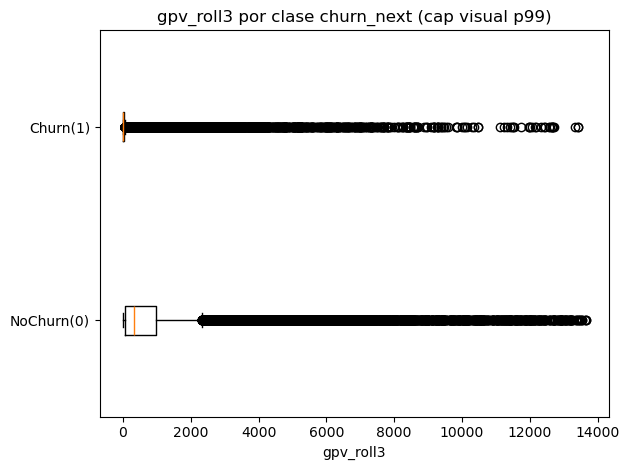

In [63]:
def box_by_target(col):
    data0 = panel.loc[panel["churn_next"]==0, col].dropna()
    data1 = panel.loc[panel["churn_next"]==1, col].dropna()
    # cap visual p99 para evitar plots rotos
    cap0 = data0.quantile(0.99) if len(data0) else None
    cap1 = data1.quantile(0.99) if len(data1) else None
    cap = np.nanmax([cap0, cap1]) if (cap0 is not None and cap1 is not None) else None
    if cap is not None:
        data0 = data0[data0 <= cap]
        data1 = data1[data1 <= cap]

    plt.figure()
    plt.boxplot([data0, data1], labels=["NoChurn(0)", "Churn(1)"], vert=False)
    plt.title(f"{col} por clase churn_next (cap visual p99)")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

for c in ["recency_days", "gpv_month", "rejected_rate", "trx_succeeded", "gpv_roll3"]:
    box_by_target(c)


Para visualización se utiliza una muestra aleatoria para evitar sobrecarga visual y computacional, preservando la distribución general.

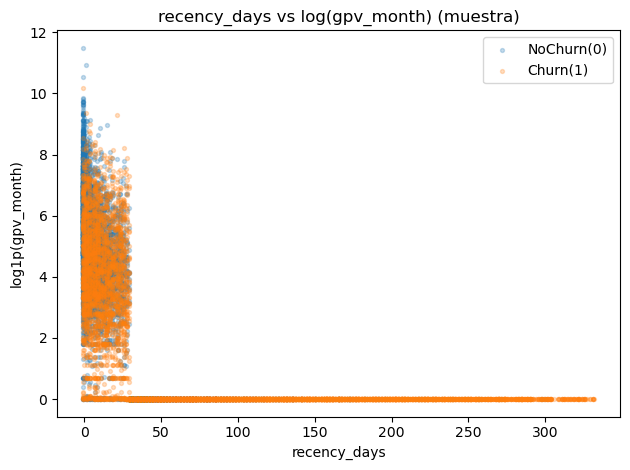

In [64]:
sample = panel.sample(n=min(20000, len(panel)), random_state=42)

s0 = sample[sample["churn_next"]==0]
s1 = sample[sample["churn_next"]==1]

plt.figure()
plt.scatter(s0["recency_days"], np.log1p(s0["gpv_month"]), s=8, alpha=0.25, label="NoChurn(0)")
plt.scatter(s1["recency_days"], np.log1p(s1["gpv_month"]), s=8, alpha=0.25, label="Churn(1)")
plt.title("recency_days vs log(gpv_month) (muestra)")
plt.xlabel("recency_days")
plt.ylabel("log1p(gpv_month)")
plt.legend()
plt.tight_layout()
plt.show()

recency_days grande significa “mucho tiempo desde la última SUCCEEDED”.

Si no hay SUCCEEDED recientes, GPV del mes tiende a 0 y el comercio se acerca a la inactividad (churn).
También se ve un “bloque” a recency bajos (0–30 días) con GPV variados: comercios que sí transaccionan.

El gráfico nos dice que conforme sube recency, GPV cae a 0 y se acerca la inactividad.
Usaremos una escala logaritmica para GPV para visualizar mejor la distribución, especialmente para los comercios con GPV bajos, que son los que están más cerca del churn.

In [65]:
churn_by_channel = panel.groupby("channel")["churn_next"].mean().mul(100).sort_values(ascending=False)
print(churn_by_channel.round(2))


channel
Outbound   71.75
Inbound    63.51
Name: churn_next, dtype: float64


In [66]:
churn_by_cat = panel.groupby("category_name")["churn_next"].mean().mul(100).sort_values(ascending=False)
churn_by_cat.round(2)


category_name
Servicios Profesionales               73.57
Electrónicos y computación            73.50
Servicio de transporte y mensajería   71.82
Ropa, calzado y accesorios            71.28
Otro                                  70.73
Artes y galerías                      68.87
Autopartes, talleres y carwash        67.28
Tiendas de conveniencia               66.36
Turismo y recreación                  65.01
Educación y deportes                  62.70
Belleza y cuidado personal            61.43
Médicos y profesionales de salud      57.38
Restaurantes, bares y hostelería      56.31
Name: churn_next, dtype: float64

In [67]:
churn_by_kyc = panel.groupby("kyc_max_level")["churn_next"].mean().mul(100).sort_index()
print(churn_by_kyc.round(2))


kyc_max_level
1   80.37
2   64.03
Name: churn_next, dtype: float64


## Panel Activo


In [68]:
panel_active = panel[panel["active_month"] == 1].copy()

print("base activa:", panel_active.shape[0])
print("Churn rate base activa (%):", round(panel_active["churn_next"].mean()*100, 2))
print(panel_active["churn_next"].value_counts(normalize=True).mul(100).round(2))


base activa: 41543
Churn rate base activa (%): 26.18
churn_next
0   73.82
1   26.18
Name: proportion, dtype: float64


Counts:
 churn_next
0    30669
1    10874
Name: count, dtype: int64

Percent:
 churn_next
0   73.82
1   26.18
Name: proportion, dtype: float64


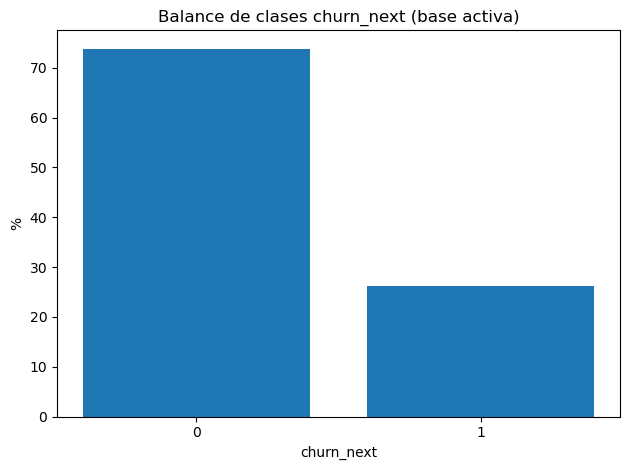

In [69]:
counts = panel_active["churn_next"].value_counts()
pct = panel_active["churn_next"].value_counts(normalize=True) * 100
print("Counts:\n", counts)
print("\nPercent:\n", pct.round(2))

plt.figure()
plt.bar(pct.index.astype(str), pct.values)
plt.title("Balance de clases churn_next (base activa)")
plt.xlabel("churn_next")
plt.ylabel("%")
plt.tight_layout()
plt.show()


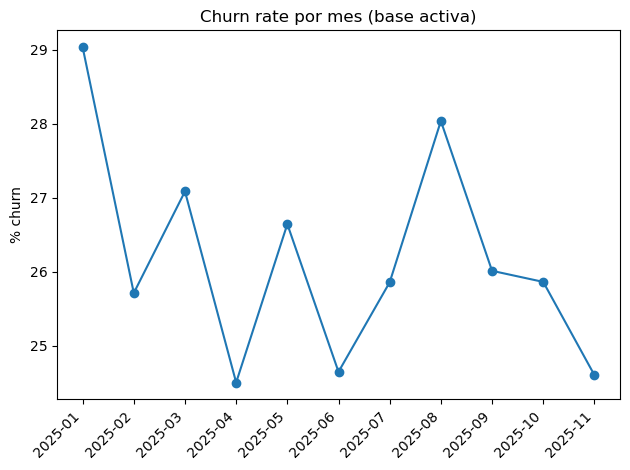

trx_month
2025-01   29.04
2025-02   25.71
2025-03   27.09
2025-04   24.50
2025-05   26.64
2025-06   24.65
2025-07   25.86
2025-08   28.04
2025-09   26.01
2025-10   25.86
2025-11   24.60
Freq: M, Name: churn_next, dtype: float64

In [70]:
churn_by_month = panel_active.groupby("trx_month")["churn_next"].mean().mul(100).sort_index()

plt.figure()
plt.plot(churn_by_month.index.astype(str), churn_by_month.values, marker="o")
plt.title("Churn rate por mes (base activa)")
plt.xticks(rotation=45, ha="right")
plt.ylabel("% churn")
plt.tight_layout()
plt.show()

churn_by_month.round(2)


channel
Inbound    26.79
Outbound   22.88
Name: churn_next, dtype: float64


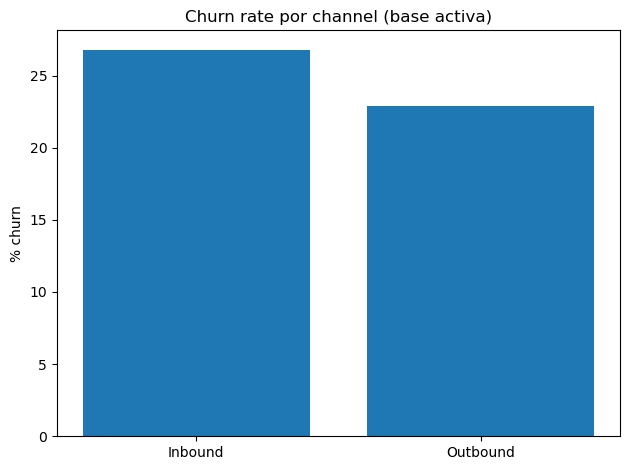

In [71]:
churn_by_channel = panel_active.groupby("channel")["churn_next"].mean().mul(100).sort_values(ascending=False)
print(churn_by_channel.round(2))

plt.figure()
plt.bar(churn_by_channel.index.astype(str), churn_by_channel.values)
plt.title("Churn rate por channel (base activa)")
plt.ylabel("% churn")
plt.tight_layout()
plt.show()


In [72]:
cat_stats = panel_active.groupby("category_name").agg(
    n=("churn_next", "size"),
    churn_rate=("churn_next", "mean")
)
cat_stats["churn_rate"] = cat_stats["churn_rate"] * 100
cat_stats = cat_stats.sort_values("n", ascending=False)

cat_stats.head(13)


,n,churn_rate
category_name,,
"Restaurantes, bares y hostelería",10743,16.16
Otro,6532,32.15
Belleza y cuidado personal,4673,24.03
Médicos y profesionales de salud,4181,25.16
"Ropa, calzado y accesorios",3012,32.24
"Autopartes, talleres y carwash",2758,34.26
Tiendas de conveniencia,2380,22.35
Electrónicos y computación,1722,38.73
Servicios Profesionales,1647,34.91


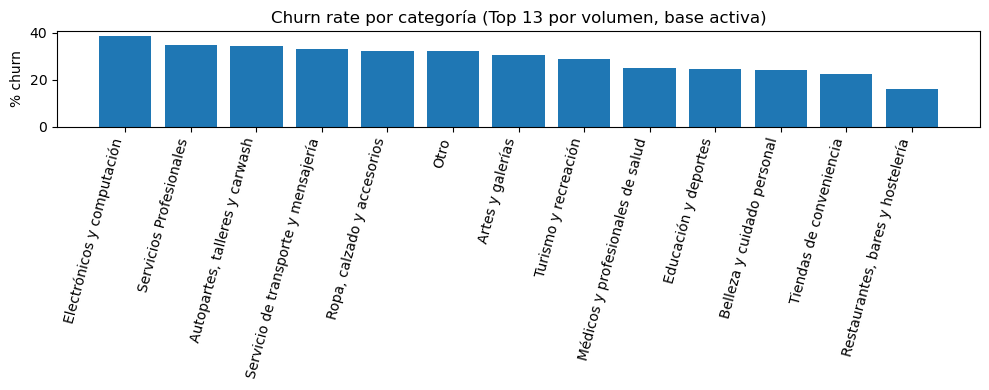

In [73]:
top_cats = cat_stats.head(13).sort_values("churn_rate", ascending=False)

plt.figure(figsize=(10,4))
plt.bar(top_cats.index.astype(str), top_cats["churn_rate"].values)
plt.title("Churn rate por categoría (Top 13 por volumen, base activa)")
plt.xticks(rotation=75, ha="right")
plt.ylabel("% churn")
plt.tight_layout()
plt.show()


In [74]:
num_cols = [
    "gpv_month", "trx_succeeded", "trx_rejected", "rejected_rate",
    "avg_ticket", "gpv_lag1", "gpv_roll3", "trx_succ_roll3",
    "delta_gpv", "pct_change_gpv",
    "recency_days", "merchant_age_days"
]

summary = panel_active.groupby("churn_next")[num_cols].median(numeric_only=True).T
summary.columns = ["NoChurn(0)", "Churn(1)"]
summary["diff"] = summary["Churn(1)"] - summary["NoChurn(0)"]
summary.sort_values("diff", ascending=False)


,NoChurn(0),Churn(1),diff
avg_ticket,26.50,39.55,13.05
recency_days,1.00,9.00,8.00
delta_gpv,36.00,41.15,5.15
rejected_rate,0.00,0.00,0.00
trx_rejected,0.00,0.00,0.00
pct_change_gpv,0.00,0.00,0.00
trx_succeeded,7.00,2.00,-5.00
merchant_age_days,402.00,393.00,-9.00
trx_succ_roll3,17.00,4.00,-13.00
gpv_month,205.90,97.38,-108.53




Recency_days separa muy bien: mediana NoChurn vs Churn  y es comercios que churn tienden a “venir enfriándose” (más días desde última transacción exitosa).



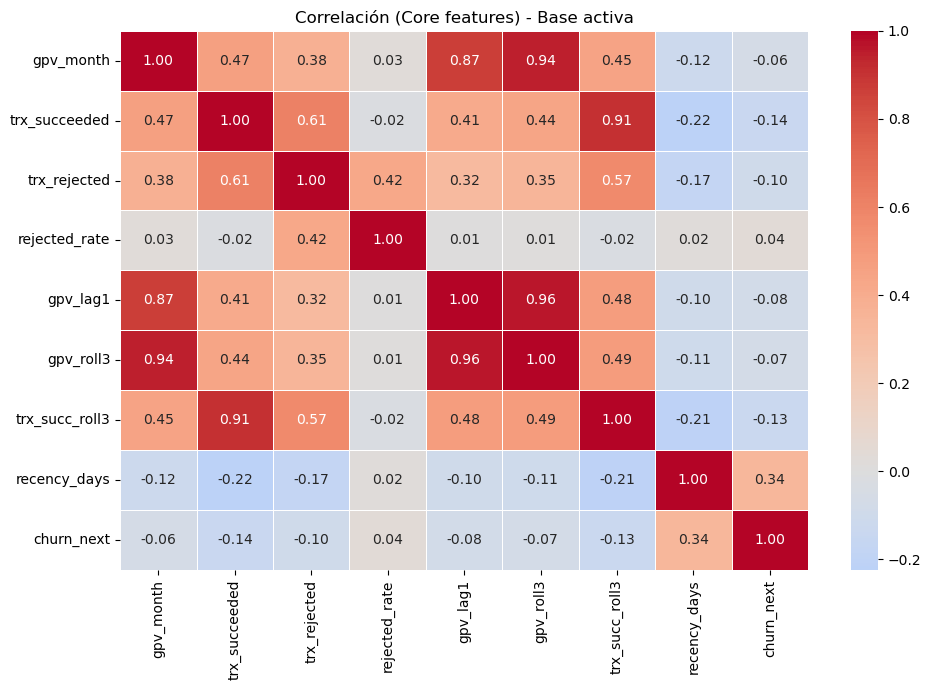

In [75]:

core_cols = ["gpv_month","trx_succeeded","trx_rejected","rejected_rate",
             "gpv_lag1","gpv_roll3","trx_succ_roll3","recency_days" ,"churn_next"]

corr = panel_active[core_cols].corr()

plt.figure(figsize=(10,7))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f", linewidths=0.5)
plt.title("Correlación (Core features) - Base activa")
plt.tight_layout()
plt.show()


## Conclusiones de EDA

- El churn rate en la base activa es del 26.18%, lo que indica que aproximadamente 1 de cada 4 comercios activos en un mes dado se vuelven inactivos en el siguiente mes.
- El churn rate muestra una tendencia creciente a lo largo de los meses, lo que podría indicar un deterioro en la retención de clientes a lo largo del tiempo o efectos estacionales.
- Recency days es una variable que tiene relacion directa con el churn, ya que los comercios que se desactivan tienden a tener una mayor cantidad de días desde su última transacción exitosa
-gpv month tiene una relacion lineal con el target casi nula, lo que indica que el monto transaccionado en el mes no es un buen predictor por sí solo del churn, aunque puede ser útil en combinación con otras variables o en su forma de cambio respecto al mes anterior (delta_gpv, pct_change_gpv).


# Estrategia de validación

División de datos tipo hold-out temporal

Train: 2025-01 a 2025-09

Validación: 2025-10

Test (final): 2025-11

Justificación:

Train grande de 9 meses para aprender patrones. (80 %)

Validación de 1 mes para elegir modelo/hiperparámetros y evitar overfitting.

Test 1 mes como evaluación final


In [76]:
# 1. Aseguramos el orden y formato
data = panel_active.copy()
data = data.sort_values(["trx_month", "company_id"]).reset_index(drop=True)
data["month_str"] = data["trx_month"].astype(str) # Blindaje contra formatos

# 2. Split Temporal
train = data[data["month_str"] <= "2025-09"].copy()
valid = data[data["month_str"] == "2025-10"].copy()
test  = data[data["month_str"] == "2025-11"].copy()

train_porcent = len(train)/len(data)*100
valid_porcent = len(valid)/len(data)*100
test_porcent = len(test)/len(data)*100

# 3. Sanity Check Final
print(f"Train: {train['month_str'].min()} a {train['month_str'].max()} | Shape: {train.shape} Porcentaje Data: {train_porcent:.2f}")
print(f"Valid: {valid['month_str'].min()} a {valid['month_str'].max()} | Shape: {valid.shape} Porcentaje Data: {valid_porcent:.2f}")
print(f"Test : {test['month_str'].min()} a {test['month_str'].max()} | Shape: {test.shape} Porcentaje Data: {test_porcent:.2f}")

# Verificamos que el Churn sea estable
print(f"Churn Train: {train['churn_next'].mean():.2%}")
print(f"Churn Valid: {valid['churn_next'].mean():.2%}")
print(f"Churn Test : {test['churn_next'].mean():.2%}")

Train: 2025-01 a 2025-09 | Shape: (33460, 29) Porcentaje Data: 80.54
Valid: 2025-10 a 2025-10 | Shape: (4002, 29) Porcentaje Data: 9.63
Test : 2025-11 a 2025-11 | Shape: (4081, 29) Porcentaje Data: 9.82
Churn Train: 26.40%
Churn Valid: 25.86%
Churn Test : 24.60%


# Preprocesamiento y Feature Engineering #



### Manejo de valores faltantes
- **`state_name` / `city_name`**: se eliminan por alto porcentaje de nulos y porque no aportan valor en el alcance del proyecto (además, imputarlas correctamente requeriría fuentes externas o lógica compleja).
- **`recency_days`**: puede quedar `NaN` si el comercio no tuvo ninguna transacción **SUCCEEDED** hasta ese mes. En ese caso se imputará dentro del pipeline (p. ej., con la **mediana** del conjunto de entrenamiento).
- **Variables categóricas (`category_name`, `channel`)**: no deberían ser nulas tras construir el panel; si aparecieran nulos, se imputarán con **"Unknown"** (o la moda del entrenamiento).

### Manejo de outliers
- Variables monetarias como **`gpv_month`** y agregados relacionados presentan una distribución altamente sesgada.
- No se eliminarán outliers, ya que pueden representar comercios grandes y comportamiento real del negocio.
- Para estabilizar la escala se aplicará transformación logarítmica: **`log1p(gpv_month)`** y **`log1p(gpv_roll3)`** ).

### Encoding de variables categóricas
- **`channel`** (Inbound/Outbound) y **`category_name`** (13 categorías) se codificarán mediante **One-Hot Encoding (OHE)** por su baja cardinalidad.
- **`kyc_max_level`** se tratará como variable numérica ordinal

### Escalamiento / normalización
- Se aplicará **StandardScaler** a variables numéricas para algoritmos sensibles a escala (p. ej., Regresión Logística con regularización, SVM, KNN).
- Para modelos basados en árboles/boosting no es estrictamente necesario, pero se mantendrá el pipeline por consistencia y reproducibilidad.

### Feature selection
- Con base en el EDA se priorizan variables con separación clara entre clases (p. ej., `recency_days`, variables de GPV y actividad reciente como `trx_succ_roll3`).
- Variables potencialmente redundantes se mantienen inicialmente y se ajustarán según importancia/performance durante el modelado.

### Prevención de data leakage
- Todo el preprocesamiento (imputación, encoding, transformaciones y escalamiento) se ajustará **solo** con el conjunto de **entrenamiento** y se aplicará de forma consistente a **validación** y **prueba**.


## Features finales para modelado

### Variables numéricas
- `recency_days`: Número de días desde la última transacción realizada por el comercio
- `merchant_age_days`: Antigüedad del comercio en días desde su registro en la plataforma
- `avg_ticket`: Monto promedio por transacción
- `rejected_rate`: Proporción de transacciones rechazadas respecto al total
- `trx_succeeded`: Número total de transacciones exitosas en el período actual
- `trx_succ_roll3`: Suma de transacciones exitosas en una ventana móvil de 3 períodos (ej. meses).
- `gpv_month`: Gross Payment Volume (GPV) del mes actual
- `gpv_roll3`: GPV acumulado en los últimos 3 períodos
- `delta_gpv`: Diferencia absoluta entre GPV actual y GPV previo
- `pct_change_gpv`: Cambio porcentual del GPV respecto al período anterior
- `kyc_max_level`: Nivel máximo de verificación KYC (Know Your Customer) alcanzado por el comercio

### Variables categóricas
- `channel`: Canal principal de operación del comercio POS fisico o digital
- `category_name`: Categoría comercial del negocio (ej. retail, restaurantes, servicios, etc.).

### Variable objetivo (target)
- `churn_next`: Variable binaria que indica si el comercio churnea en el siguiente período. 1 → churn (abandono/inactividad) 0 → activo


In [77]:
# 1. Definimos la lista final de Features (sin gpv_lag1 por ser redundante)
features = [
    # Numéricas
    'recency_days', 'merchant_age_days', 'avg_ticket', 'rejected_rate',
    'trx_succeeded', 'trx_succ_roll3', 'gpv_month',
    'gpv_roll3', 'delta_gpv', 'pct_change_gpv', 'kyc_max_level',
    # Categóricas
    'channel', 'category_name'
]

target = 'churn_next'

# 2. Creamos las matrices X,y
X_train = train[features].copy()
y_train = train[target].copy()

X_valid = valid[features].copy()
y_valid = valid[target].copy()

X_test = test[features].copy()
y_test = test[target].copy()

In [78]:
# 1. Identificamos qué hacer con cada columna
num_features = [
    'recency_days', 'merchant_age_days', 'avg_ticket', 'rejected_rate',
    'trx_succeeded', 'trx_succ_roll3', 'gpv_month', 'gpv_roll3',
    'delta_gpv', 'pct_change_gpv', 'kyc_max_level'
]

cat_features = ['channel', 'category_name']

# 2. Definimos el preprocesador
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ]
)

In [79]:

# Fit SOLO en train
X_train_scaled = preprocessor.fit_transform(X_train)
X_valid_scaled = preprocessor.transform(X_valid)
X_test_scaled  = preprocessor.transform(X_test)

print("X_train_scaled:", X_train_scaled.shape, "X_valid_scaled:", X_valid_scaled.shape, "X_test_scaled:", X_test_scaled.shape)

# nombres de features resultantes, para interpretabilidad
try:
    feature_names = preprocessor.get_feature_names_out()
    print("Total features after preprocessing:", len(feature_names))
except Exception as e:
    print("No feature names available:", e)

print(f"Variables seleccionadas: {len(features)}")
print(f"Dimensiones X_train: {X_train.shape}")

X_train_scaled: (33460, 26) X_valid_scaled: (4002, 26) X_test_scaled: (4081, 26)
Total features after preprocessing: 26
Variables seleccionadas: 13
Dimensiones X_train: (33460, 13)


# Almacenar data final

In [80]:

#Exportamos las variables X,y de cada cojunto de entrenamiento, validacion y test para solo importarlos en otros notebooks
# Configuración de nombres (asumiendo que usaste .npz o .pkl)
archivo_final = 'datos_modelo_dl.npz'

np.savez_compressed(archivo_final,
                    X_train=X_train_scaled, y_train=y_train,
                    X_val=X_valid_scaled, y_val=y_valid,
                    X_test=X_test_scaled, y_test=y_test)



if os.path.exists(archivo_final):
    print("="*50)
    print("¡PROCESO FINALIZADO CON ÉXITO! 🚀")
    print("="*50)
    print(f"✅ Archivo guardado: {archivo_final}")
    print(f"📦 Tamaño del archivo: {os.path.getsize(archivo_final) / (1024*1024):.2f} MB")
    print(f"📊 Registros totales procesados: {len(X_train_scaled) + len(X_valid_scaled) + len(X_test_scaled):,}")
    print("-"*50)
    print("💡 Todo listo para importar en tu siguiente Notebook.")
else:
    print("⚠️ Error: El archivo no se encontró. Revisa la ruta de guardado.")

¡PROCESO FINALIZADO CON ÉXITO! 🚀
✅ Archivo guardado: datos_modelo_dl.npz
📦 Tamaño del archivo: 2.07 MB
📊 Registros totales procesados: 41,543
--------------------------------------------------
💡 Todo listo para importar en tu siguiente Notebook.
